# Section - XGBoost Model

TRY NEW MODEL - APRIL 2026 <br>
Updated on  : 21/04/2026 

# 1. Load Function

In [28]:
import pandas as pd
import numpy as np
import re
import pickle
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# 2. Load Files

In [29]:
# ============================================================
# 📂 LOAD & COMBINE ALL PROJECT FILES
# ============================================================
print("=" * 100)
print("📊 LOADING DATA")
print("=" * 100)
 
folder_path = r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\dummy_data"
 
dfs = []
for file in os.listdir(folder_path):
    if file.endswith(".xlsx"):
        path = os.path.join(folder_path, file)
        try:
            df_temp = pd.read_excel(path)
            df_temp.columns = df_temp.columns.str.upper()
            dfs.append(df_temp)
            print(f"   ✅ Loaded: {file} — {len(df_temp)} rows")
        except Exception as e:
            print(f"   ⚠ Skipped ({e}): {file}")
 
if not dfs:
    raise ValueError("No Excel files found or loaded from the specified folder.")
 
df = pd.concat(dfs, ignore_index=True)
 
print(f"\n   Total records : {len(df)}")
print(f"   Columns       : {', '.join(df.columns)}")
print(f"\n📋 Preview:\n{df.head(10)}")


📊 LOADING DATA
   ✅ Loaded: Oiltek_A1706.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9991.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9992.xlsx — 93 rows
   ✅ Loaded: Oiltek_A9993.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9994.xlsx — 108 rows
   ✅ Loaded: Oiltek_A9995.xlsx — 108 rows
   ✅ Loaded: UGS_A2027.xlsx — 328 rows
   ✅ Loaded: UGS_A8881.xlsx — 86 rows
   ✅ Loaded: UGS_A8882.xlsx — 115 rows
   ✅ Loaded: UGS_A8883.xlsx — 115 rows
   ✅ Loaded: UGS_A8884.xlsx — 115 rows
   ✅ Loaded: UGS_A8885.xlsx — 116 rows
   ⚠ Skipped ([Errno 13] Permission denied: 'C:\\Users\\sitisyaziyah\\source\\repos\\DeviceCluster\\1.training_model\\dummy_data\\~$Oiltek_A1706.xlsx'): ~$Oiltek_A1706.xlsx
   ⚠ Skipped ([Errno 13] Permission denied: 'C:\\Users\\sitisyaziyah\\source\\repos\\DeviceCluster\\1.training_model\\dummy_data\\~$Oiltek_A9993.xlsx'): ~$Oiltek_A9993.xlsx

   Total records : 1568
   Columns       : CUSTOMER, PROJECT, SECTION, CLUSTER, DEVICE_ID

📋 Preview:
  CUSTOMER PROJECT    SECTION    CLUSTER DEVICE_ID
0

# Safe Label Encoder

In [30]:
class SafeLabelEncoder:
    """
    A LabelEncoder that:
      - Adds an '__UNKNOWN__' class during fit.
      - Returns the index of '__UNKNOWN__' for any unseen
        label during transform, instead of crashing.
      - Provides is_known(values) for explicit gate checks.
 
    Usage is identical to LabelEncoder:
        le = SafeLabelEncoder()
        le.fit(series)
        encoded = le.transform(series)
        decoded = le.inverse_transform(encoded_array)
    """
 
    UNKNOWN_LABEL = "__UNKNOWN__"
    
    # Set up the encoder and prepare an empty class list
    def __init__(self):
        self._le = LabelEncoder()
        self.classes_ = None

    # Learn all unique labels, reserving a slot for unknowns
    def fit(self, y):
        labels = list(pd.Series(y).astype(str).unique())
        if self.UNKNOWN_LABEL not in labels:
            labels = [self.UNKNOWN_LABEL] + labels
        self._le.fit(labels)
        self.classes_ = self._le.classes_
        return self
    
    # Encode labels, safely rerouting unseen values to __UNKNOWN__
    def transform(self, y):
        y_str = pd.Series(y).astype(str)
        known = set(self.classes_)
        y_safe = y_str.where(y_str.isin(known), other=self.UNKNOWN_LABEL)
        return self._le.transform(y_safe)
 
    # Fit and encode in one pass
    def fit_transform(self, y):
        return self.fit(y).transform(y)
    
    # Decode integers back to their original labels
    def inverse_transform(self, y):
        return self._le.inverse_transform(y)
    
    # Flag values unseen during training
    def is_known(self, values):
        """Return a boolean Series: True if value is known (not __UNKNOWN__)."""
        known = set(self.classes_) - {self.UNKNOWN_LABEL}
        return pd.Series(values).astype(str).isin(known)

# 3. Feature Engineering

In [ ]:
# script after removal prefixes extraction + numeric block convention features (28/4/2026) 03:41 pm
print("\n" + "=" * 100)
print("🔧 FEATURE ENGINEERING  (suffix + numeric only — prefix excluded)")
print("=" * 100)

# Extract: first number found in the device ID (as integer — strips leading zeros)
def extract_numeric_block(device_id):
    match = re.search(r'\d+', str(device_id))
    return int(match.group()) if match else -1

# Extract: raw digit string preserving leading zeros  e.g. "051", "0000000021"
def extract_numeric_string(device_id):
    match = re.search(r'\d+', str(device_id))
    return match.group() if match else ''

# Extract: letters immediately after the trailing number
def extract_suffix_letters(device_id):
    match = re.search(r'\d+([A-Za-z]*)$', str(device_id))
    return match.group(1).upper() if match else ''

# Extract: everything after the trailing number
def extract_suffix_full(device_id):
    match = re.search(r'\d+(.*)$', str(device_id))
    return match.group(1) if match else ''

# Extract: numeric digits from a section string
def extract_section_num(section_str):
    digits = ''.join(c for c in str(section_str) if c.isdigit())
    return int(digits) if digits else 0

# Extract: numeric digits from a cluster string
def extract_cluster_num(cluster_str):
    digits = ''.join(c for c in str(cluster_str) if c.isdigit())
    return int(digits) if digits else 0

# ── Numeric block features ────────────────────────────────────
df['numeric_block']         = df['DEVICE_ID'].apply(extract_numeric_block)
df['device_suffix_letter']  = df['DEVICE_ID'].apply(extract_suffix_letters)
df['suffix_full']           = df['DEVICE_ID'].apply(extract_suffix_full)
df['device_id_length']      = df['DEVICE_ID'].astype(str).str.len()
df['has_suffix_letter']     = (df['device_suffix_letter'] != '').astype(int)
df['has_numeric']           = (df['numeric_block'] != -1).astype(int)

# ── Numeric block convention features ────────────────────────
print("\n   Creating numeric block convention features...")

_numeric_raw_str              = df['DEVICE_ID'].apply(extract_numeric_string)

# Total digit characters including leading zeros  e.g. "051"→3, "0000000021"→10
df['count_num_digit']         = _numeric_raw_str.str.len()

# Significant value after stripping leading zeros (same as numeric_block but explicit)
df['numeric_remove_zero']     = df['numeric_block']

# Digit count of the significant value  e.g. 51→2, 1→1, 21→2, 102837→6
df['count_num_remove_zero']   = df['numeric_remove_zero'].apply(
                                    lambda x: len(str(x)) if x != -1 else 0)

# Number of leading zeros = full width minus significant digit count
# e.g. "051"→1, "001"→2, "0000000021"→8  ← convention fingerprint
df['leading_zero_count']      = df['count_num_digit'] - df['count_num_remove_zero']

print("   ✅ Numeric block convention features created")

# ── Advanced suffix features ──────────────────────────────────
print("\n   Creating advanced suffix features...")

df['suffix_length']             = df['suffix_full'].astype(str).str.len()
df['suffix_has_digit']          = df['suffix_full'].astype(str).str.contains(r'\d', regex=True).astype(int)
df['suffix_has_letter']         = df['suffix_full'].astype(str).str.contains(r'[A-Za-z]', regex=True).astype(int)
df['suffix_has_decimal']        = df['suffix_full'].astype(str).str.contains(r'\.', regex=True).astype(int)
df['suffix_digit_count']        = df['suffix_full'].astype(str).str.count(r'\d')
df['suffix_letter_count']       = df['suffix_full'].astype(str).str.count(r'[A-Za-z]')
df['suffix_starts_with_digit']  = df['suffix_full'].astype(str).str[0].str.isdigit().fillna(0).astype(int)
df['suffix_last_char']          = df['suffix_full'].astype(str).str[-1]
df['suffix_last_char_is_letter']= df['suffix_last_char'].str.isalpha().fillna(0).astype(int)
df['suffix_last_char_is_digit'] = df['suffix_last_char'].str.isdigit().fillna(0).astype(int)

df['equip_id_length']           = df['DEVICE_ID'].astype(str).str.len()
df['equip_id_digit_count']      = df['DEVICE_ID'].astype(str).str.count(r'\d')

print("   ✅ Advanced suffix features created")

# ── Numeric block rank within project ────────────────────────
def assign_block_rank(group):
    unique_blocks = sorted(group['numeric_block'].unique())
    block_to_rank = {b: i + 1 for i, b in enumerate(unique_blocks)}
    return group['numeric_block'].map(block_to_rank)

df['numeric_block_rank'] = df.groupby(['CUSTOMER', 'PROJECT'], group_keys=False).apply(assign_block_rank)

print("   ✅ numeric_block_rank created")
print(f"\n   Sample feature preview:")
print(df[['CUSTOMER', 'PROJECT', 'DEVICE_ID',
          'numeric_block', 'count_num_digit', 'leading_zero_count',
          'count_num_remove_zero', 'suffix_full', 'suffix_last_char',
          'numeric_block_rank', 'SECTION']].head(15))


🔧 FEATURE ENGINEERING  (suffix + numeric only — prefix excluded)

   Creating numeric block convention features...
   ✅ Numeric block convention features created

   Creating advanced suffix features...
   ✅ Advanced suffix features created
   ✅ numeric_block_rank created

   Sample feature preview:
   CUSTOMER PROJECT DEVICE_ID  numeric_block  count_num_digit  \
0    OILTEK   A1706      A500            500                3   
1    OILTEK   A1706     HT500            500                3   
2    OILTEK   A1706    PT500A            500                3   
3    OILTEK   A1706    PV500B            500                3   
4    OILTEK   A1706     TE500            500                3   
5    OILTEK   A1706    HLA600            600                3   
6    OILTEK   A1706     DV601            601                3   
7    OILTEK   A1706     FB601            601                3   
8    OILTEK   A1706    HLA601            601                3   
9    OILTEK   A1706    LLA601            601    

# 4. Label Encoding

In [34]:
# new script after removing prefixes

print("\n" + "=" * 100)
print("🔤 ENCODING CATEGORICAL VARIABLES  (SafeLabelEncoder — suffix only)")
print("=" * 100)

le_suffix_letter  = SafeLabelEncoder()
le_suffix_last    = SafeLabelEncoder()
le_section        = SafeLabelEncoder()
le_cluster        = SafeLabelEncoder()

df['suffix_letter_enc']    = le_suffix_letter.fit_transform(df['device_suffix_letter'])
df['suffix_last_char_enc'] = le_suffix_last.fit_transform(df['suffix_last_char'])
df['section_enc']          = le_section.fit_transform(df['SECTION'])
df['cluster_enc']          = le_cluster.fit_transform(df['CLUSTER'])

print(f"   Section classes : {list(le_section.classes_)}")
print(f"   Cluster classes : {list(le_cluster.classes_)}")




🔤 ENCODING CATEGORICAL VARIABLES  (SafeLabelEncoder — suffix only)
   Section classes : [np.str_('SECTION 1'), np.str_('SECTION 2'), np.str_('SECTION 3'), np.str_('SECTION 4'), np.str_('SECTION 5'), np.str_('SECTION 6'), np.str_('__UNKNOWN__')]
   Cluster classes : [np.str_('CLUSTER 1'), np.str_('CLUSTER 2'), np.str_('CLUSTER 3'), np.str_('CLUSTER 4'), np.str_('CLUSTER 5'), np.str_('CLUSTER 6'), np.str_('CLUSTER 7'), np.str_('CLUSTER 8'), np.str_('CLUSTER 9'), np.str_('__UNKNOWN__')]


# 5. Features & Targets

In [ ]:

feature_columns = [
    'DEVICE_ID',                  # traceability only — not fed to model

    # ── Numeric block: raw ───────────────────────────────────
    'numeric_block',              # significant integer value (leading zeros stripped)
    'numeric_block_rank',         # rank within project context

    # ── Numeric block: convention fingerprint ────────────────
    'count_num_digit',            # full field width incl. leading zeros  e.g. "051"→3
    'count_num_remove_zero',      # significant digit count               e.g. 51→2
    'numeric_remove_zero',        # significant value (explicit alias of numeric_block)
    'leading_zero_count',         # padding depth = convention identifier e.g. "051"→1

    # ── Device ID structural ─────────────────────────────────
    'device_id_length',
    'has_suffix_letter',
    'has_numeric',
    'equip_id_length',
    'equip_id_digit_count',

    # ── Suffix features ──────────────────────────────────────
    'suffix_letter_enc',
    'suffix_length',
    'suffix_has_digit',
    'suffix_has_letter',
    'suffix_has_decimal',
    'suffix_digit_count',
    'suffix_letter_count',
    'suffix_starts_with_digit',
    'suffix_last_char_enc',
    'suffix_last_char_is_letter',
    'suffix_last_char_is_digit',
]

X = df[feature_columns]
y_section = df['section_enc']
y_cluster = df['cluster_enc']

print(f"\n   Total features : {len(feature_columns)}")
print(f"   Feature list   : {feature_columns}")


   Total features : 23
   Feature list   : ['DEVICE_ID', 'numeric_block', 'numeric_block_rank', 'count_num_digit', 'count_num_remove_zero', 'numeric_remove_zero', 'leading_zero_count', 'device_id_length', 'has_suffix_letter', 'has_numeric', 'equip_id_length', 'equip_id_digit_count', 'suffix_letter_enc', 'suffix_length', 'suffix_has_digit', 'suffix_has_letter', 'suffix_has_decimal', 'suffix_digit_count', 'suffix_letter_count', 'suffix_starts_with_digit', 'suffix_last_char_enc', 'suffix_last_char_is_letter', 'suffix_last_char_is_digit']


# 6. Chain model (train, val, test)

In [37]:
# ============================================================
# ✂️ TRAIN / VAL / TEST SPLIT (DataFrame-based)
# ============================================================
print("\n" + "=" * 100)
print("✂️  SPLITTING DATA")
print("=" * 100)


def safe_split_df(df, label_col, test_size=0.15, val_size=0.176, max_attempts=100):
    y = df[label_col]
    all_classes = set(np.unique(y))

    for attempt in range(max_attempts):
        
        idx_tmp, idx_test = train_test_split(
            # Split test set
            df.index,
            test_size=test_size,
            random_state=42 + attempt,
            stratify=y,
            shuffle=True
        )
        # Split train and validation
        idx_train, idx_val = train_test_split(
            idx_tmp,
            test_size=val_size,
            random_state=42 + attempt,
            stratify=y.loc[idx_tmp],
            shuffle=True
        )
        if set(np.unique(y.loc[idx_train])) == all_classes:
            print(f"   ✅ Valid split on attempt {attempt + 1}")
            break
    else:
        print("   ⚠ Using last split (not all classes in train)")

    train_df = df.loc[idx_train].copy().reset_index(drop=False)
    val_df   = df.loc[idx_val].copy().reset_index(drop=False)
    test_df  = df.loc[idx_test].copy().reset_index(drop=False)

    # tag split type
    train_df["_split"] = "train"
    val_df["_split"]   = "val"
    test_df["_split"]  = "test"

    return train_df, val_df, test_df


full_df = X.copy()
full_df["y_section"] = y_section
full_df["y_cluster"]  = y_cluster

train_df, val_df, test_df = safe_split_df(full_df, label_col="y_section")

feature_cols = X.columns.tolist()


def extract_features(df, cols):
    X_out = df[cols].apply(pd.to_numeric, errors='coerce')
    bad   = X_out.dtypes[X_out.dtypes == 'object'].index.tolist()
    if bad:
        print(f"   ⚠ Dropping non-numeric columns: {bad}")
        X_out = X_out.drop(columns=bad)
    return X_out.fillna(0)


X_train = extract_features(train_df, feature_cols)
X_val   = extract_features(val_df,   feature_cols)
X_test  = extract_features(test_df,  feature_cols)

y_sec_train = train_df["y_section"]
y_sec_val   = val_df["y_section"]
y_sec_test  = test_df["y_section"]

y_clu_train = train_df["y_cluster"]
y_clu_val   = val_df["y_cluster"]
y_clu_test  = test_df["y_cluster"]

print(f"\n   Train : {len(train_df):,} rows")
print(f"   Val   : {len(val_df):,} rows")
print(f"   Test  : {len(test_df):,} rows")
print(f"   Feature shape (train) : {X_train.shape}")


# ============================================================
# 🚀 STAGE 1 — SECTION MODEL
# ============================================================
print("\n" + "=" * 100)
print("🚀 STAGE 1 — TRAINING SECTION MODEL")
print("=" * 100)


def build_model(n_classes):
    return xgb.XGBClassifier(
        objective        = 'multi:softprob',
        num_class        = n_classes,
        max_depth        = 6,
        learning_rate    = 0.05,
        n_estimators     = 300,
        min_child_weight = 1,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        gamma            = 0.1,
        random_state     = 42,
        eval_metric      = 'mlogloss',
    )


# Exclude __UNKNOWN__ from class count — it is a SafeLabelEncoder sentinel,
# not a real training class. Passing len(le.classes_) directly would give
# XGBoost the wrong num_class and cause a mismatch downstream.
n_section_classes = sum(1 for c in le_section.classes_ if c != "__UNKNOWN__")
n_cluster_classes = sum(1 for c in le_cluster.classes_ if c != "__UNKNOWN__")

model_section = build_model(n_section_classes)
model_section.fit(
    X_train, y_sec_train,
    eval_set=[(X_train, y_sec_train), (X_val, y_sec_val)],
    verbose=False
)

y_sec_pred_train = model_section.predict(X_train)
y_sec_pred_val   = model_section.predict(X_val)
y_sec_pred_test  = model_section.predict(X_test)

print(f"\n   🎯 Section Test Accuracy: {accuracy_score(y_sec_test, y_sec_pred_test):.2%}")

sec_labels = sorted(set(y_sec_test) | set(y_sec_pred_test))
print(classification_report(
    y_sec_test, y_sec_pred_test,
    labels=sec_labels,
    target_names=[le_section.classes_[i] for i in sec_labels],
    zero_division=0
))


# ============================================================
# 🔗 CHAIN — INJECT SECTION PREDICTION INTO CLUSTER FEATURES
# ============================================================
print("\n" + "=" * 100)
print("🔗 CHAINING — INJECTING SECTION PREDICTION INTO CLUSTER FEATURES")
print("=" * 100)

X_train_chained = X_train.copy()
X_val_chained   = X_val.copy()
X_test_chained  = X_test.copy()

X_train_chained["predicted_section"] = y_sec_pred_train
X_val_chained["predicted_section"]   = y_sec_pred_val
X_test_chained["predicted_section"]  = y_sec_pred_test

print(f"   ✅ Feature shape after chaining: {X_train_chained.shape}")


# ============================================================
# 🚀 STAGE 2 — CLUSTER MODEL
# ============================================================
print("\n" + "=" * 100)
print("🚀 STAGE 2 — TRAINING CLUSTER MODEL")
print("=" * 100)

model_cluster = build_model(n_cluster_classes)
model_cluster.fit(
    X_train_chained, y_clu_train,
    eval_set=[(X_train_chained, y_clu_train), (X_val_chained, y_clu_val)],
    verbose=False
)

y_clu_pred = model_cluster.predict(X_test_chained)

print(f"\n   🎯 Cluster Test Accuracy: {accuracy_score(y_clu_test, y_clu_pred):.2%}")

clu_labels = sorted(set(y_clu_test) | set(y_clu_pred))
print(classification_report(
    y_clu_test, y_clu_pred,
    labels=clu_labels,
    target_names=[le_cluster.classes_[i] for i in clu_labels],
    zero_division=0
))


# ============================================================
# 📋 CHAIN SUMMARY
# ============================================================
print("\n" + "=" * 100)
print("📋 CHAINED MODEL SUMMARY")
print("=" * 100)
print(f"   Stage 1 — Section Model : {accuracy_score(y_sec_test, y_sec_pred_test):.2%} accuracy")
print(f"   Stage 2 — Cluster Model : {accuracy_score(y_clu_test, y_clu_pred):.2%} accuracy")
print(f"\n   Chain flow:")
print(f"      X_features → [Section Model] → predicted_section")
print(f"      X_features + predicted_section → [Cluster Model] → predicted_cluster")



✂️  SPLITTING DATA
   ✅ Valid split on attempt 1

   Train : 1,097 rows
   Val   : 235 rows
   Test  : 236 rows
   Feature shape (train) : (1097, 23)

🚀 STAGE 1 — TRAINING SECTION MODEL

   🎯 Section Test Accuracy: 97.88%
              precision    recall  f1-score   support

   SECTION 1       0.96      0.97      0.97        71
   SECTION 2       1.00      0.98      0.99        54
   SECTION 3       0.96      1.00      0.98        46
   SECTION 4       1.00      1.00      1.00        23
   SECTION 5       1.00      1.00      1.00        38
   SECTION 6       1.00      0.50      0.67         4

    accuracy                           0.98       236
   macro avg       0.99      0.91      0.93       236
weighted avg       0.98      0.98      0.98       236


🔗 CHAINING — INJECTING SECTION PREDICTION INTO CLUSTER FEATURES
   ✅ Feature shape after chaining: (1097, 24)

🚀 STAGE 2 — TRAINING CLUSTER MODEL

   🎯 Cluster Test Accuracy: 97.03%
              precision    recall  f1-score   suppo

# 7. Chain Model Output

In [38]:
# ============================================================
# 📋 RESULT DATAFRAME — CHAINED MODEL PREDICTIONS
# ============================================================

# ✅ TRAIN
train_df2 = train_df[["index", "DEVICE_ID", "y_section", "y_cluster", "_split"]].copy()
train_df2["actual_section"]    = le_section.inverse_transform(train_df2["y_section"])
train_df2["actual_cluster"]    = le_cluster.inverse_transform(train_df2["y_cluster"])
train_df2["pred_section"]      = le_section.inverse_transform(y_sec_pred_train)
train_df2["pred_cluster"]      = le_cluster.inverse_transform(model_cluster.predict(X_train_chained))
train_df2["section_correct"]   = train_df2["actual_section"] == train_df2["pred_section"]
train_df2["cluster_correct"]   = train_df2["actual_cluster"] == train_df2["pred_cluster"]

# ✅ VAL
val_df2 = val_df[["index", "DEVICE_ID", "y_section", "y_cluster", "_split"]].copy()
val_df2["actual_section"]      = le_section.inverse_transform(val_df2["y_section"])
val_df2["actual_cluster"]      = le_cluster.inverse_transform(val_df2["y_cluster"])
val_df2["pred_section"]        = le_section.inverse_transform(y_sec_pred_val)
val_df2["pred_cluster"]        = le_cluster.inverse_transform(model_cluster.predict(X_val_chained))
val_df2["section_correct"]     = val_df2["actual_section"] == val_df2["pred_section"]
val_df2["cluster_correct"]     = val_df2["actual_cluster"] == val_df2["pred_cluster"]

# ✅ TEST
test_df2 = test_df[["index", "DEVICE_ID", "y_section", "y_cluster", "_split"]].copy()
test_df2["actual_section"]     = le_section.inverse_transform(test_df2["y_section"])
test_df2["actual_cluster"]     = le_cluster.inverse_transform(test_df2["y_cluster"])
test_df2["pred_section"]       = le_section.inverse_transform(y_sec_pred_test)
test_df2["pred_cluster"]       = le_cluster.inverse_transform(y_clu_pred)
test_df2["section_correct"]    = test_df2["actual_section"] == test_df2["pred_section"]
test_df2["cluster_correct"]    = test_df2["actual_cluster"] == test_df2["pred_cluster"]

# ✅ COMBINE ALL SPLITS
full_result_df = pd.concat([train_df2, val_df2, test_df2], ignore_index=True)

# ✅ DIAGNOSTICS
print("\n" + "=" * 100)
print("📋 PREDICTION RESULT SUMMARY")
print("=" * 100)

for split_name, df_split in [("TRAIN", train_df2), ("VAL", val_df2), ("TEST", test_df2)]:
    sec_acc = df_split["section_correct"].mean()
    clu_acc = df_split["cluster_correct"].mean()
    print(f"\n   [{split_name}]")
    print(f"      Section Accuracy : {sec_acc:.2%}")
    print(f"      Cluster Accuracy : {clu_acc:.2%}")

print(f"\n   📊 Full result shape : {full_result_df.shape}")



📋 PREDICTION RESULT SUMMARY

   [TRAIN]
      Section Accuracy : 99.91%
      Cluster Accuracy : 99.64%

   [VAL]
      Section Accuracy : 98.30%
      Cluster Accuracy : 97.45%

   [TEST]
      Section Accuracy : 97.88%
      Cluster Accuracy : 97.03%

   📊 Full result shape : (1568, 11)


📊 Output Result (Test dataset) <br>

🔴 Case : Section ❌, Cluster ✅ <br>
🔵 Case : Section ✅, Cluster ❌

| DEVICE_ID | Actual Section | Predicted Section | Section Check | Actual Cluster | Predicted Cluster | Cluster Check |
| --------- | -------------- | ----------------- | ------------- | -------------- | ----------------- | ------------- |
| HT275     | SECTION 1      | SECTION 3         | ❌ False       | CLUSTER 1      | CLUSTER 1         | ✅ True        |
| CPM6311   | SECTION 1      | SECTION 1         | ✅ True        | CLUSTER 3      | CLUSTER 4         | ❌ False       |
| FIT151    | SECTION 3      | SECTION 3         | ✅ True        | CLUSTER 4      | CLUSTER 1         | ❌ False       |
| V29011    | SECTION 3      | SECTION 3         | ✅ True        | CLUSTER 7      | CLUSTER 4         | ❌ False       |




In [39]:
# ============================================================
# 📊 CHUNK 4 — FORMATTED RESULT TABLE (SECTION + CLUSTER CHECK)
# ============================================================

# ✅ Use TEST dataset (you can change to train/val if needed)
result_df = test_df[["DEVICE_ID"]].copy()

# --- SECTION ---
result_df["Actual Section"]    = le_section.inverse_transform(y_sec_test)
result_df["Predicted Section"] = le_section.inverse_transform(y_sec_pred_test)
result_df["Check Section"]     = result_df["Actual Section"] == result_df["Predicted Section"]

# --- CLUSTER ---
result_df["Actual Cluster"]    = le_cluster.inverse_transform(y_clu_test)
result_df["Predicted Cluster"] = le_cluster.inverse_transform(y_clu_pred)
result_df["Check Cluster"]     = result_df["Actual Cluster"] == result_df["Predicted Cluster"]

# --- Optional: Pretty display (emoji style like your screenshot) ---
def format_check(val):
    return "✅ True" if val else "❌ False"

result_df["Check Section"] = result_df["Check Section"].apply(format_check)
result_df["Check Cluster"] = result_df["Check Cluster"].apply(format_check)

# --- Display ---
print("\n📊 FORMATTED RESULT TABLE")
print("=" * 100)



pd.set_option('display.max_rows', None)
print(result_df)


📊 FORMATTED RESULT TABLE
     DEVICE_ID Actual Section Predicted Section Check Section Actual Cluster  \
0       PC1102      SECTION 1         SECTION 1        ✅ True      CLUSTER 9   
1       LL0401      SECTION 1         SECTION 1        ✅ True      CLUSTER 4   
2       VP582A      SECTION 5         SECTION 5        ✅ True      CLUSTER 1   
3       FIT101      SECTION 3         SECTION 3        ✅ True      CLUSTER 4   
4     PSL152.1      SECTION 3         SECTION 3        ✅ True      CLUSTER 4   
5       LL2103      SECTION 1         SECTION 1        ✅ True      CLUSTER 1   
6        V11.6      SECTION 4         SECTION 4        ✅ True      CLUSTER 2   
7       V45041      SECTION 3         SECTION 3        ✅ True      CLUSTER 4   
8     V11CR2DA      SECTION 2         SECTION 2        ✅ True      CLUSTER 7   
9         V8.8      SECTION 4         SECTION 4        ✅ True      CLUSTER 4   
10      TC0103      SECTION 1         SECTION 1        ✅ True      CLUSTER 1   
11      PC0794

# 8 Feature Importance


⭐ FEATURE IMPORTANCE

   [SECTION]
                   feature  importance
         suffix_has_letter    0.342479
      equip_id_digit_count    0.165407
           count_num_digit    0.103697
        suffix_has_decimal    0.080770
       suffix_letter_count    0.057275
        leading_zero_count    0.043498
          suffix_has_digit    0.037290
             numeric_block    0.035990
             suffix_length    0.032660
       numeric_remove_zero    0.031942
         suffix_letter_enc    0.019514
        numeric_block_rank    0.014390
     count_num_remove_zero    0.013487
      suffix_last_char_enc    0.004937
           equip_id_length    0.004439
          device_id_length    0.004216
        suffix_digit_count    0.003890
         has_suffix_letter    0.001767
 suffix_last_char_is_digit    0.001433
suffix_last_char_is_letter    0.000922
                 DEVICE_ID    0.000000
               has_numeric    0.000000
  suffix_starts_with_digit    0.000000

   Top 10 features for SECT

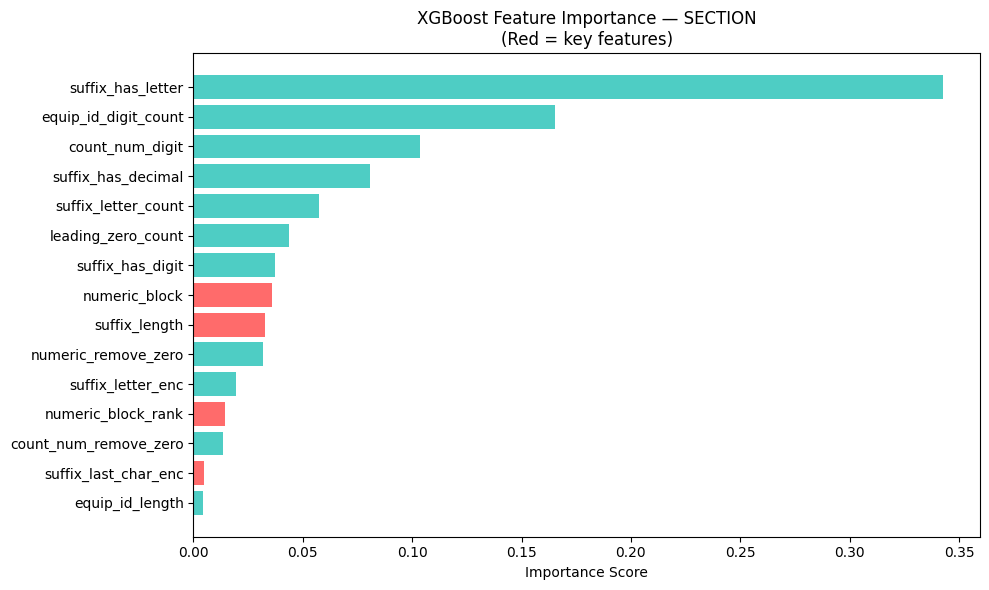


   [CLUSTER]
                   feature  importance
          suffix_has_digit    0.341559
        suffix_has_decimal    0.059595
           count_num_digit    0.058325
             suffix_length    0.056226
        suffix_digit_count    0.055732
         suffix_has_letter    0.048646
       suffix_letter_count    0.045176
suffix_last_char_is_letter    0.038479
      equip_id_digit_count    0.035790
        numeric_block_rank    0.035661
         predicted_section    0.035370
         suffix_letter_enc    0.026773
     count_num_remove_zero    0.024070
        leading_zero_count    0.022783
             numeric_block    0.021658
          device_id_length    0.021589
           equip_id_length    0.020636
         has_suffix_letter    0.017043
       numeric_remove_zero    0.015233
      suffix_last_char_enc    0.014238
 suffix_last_char_is_digit    0.005415
                 DEVICE_ID    0.000000
               has_numeric    0.000000
  suffix_starts_with_digit    0.000000

   Top 10 

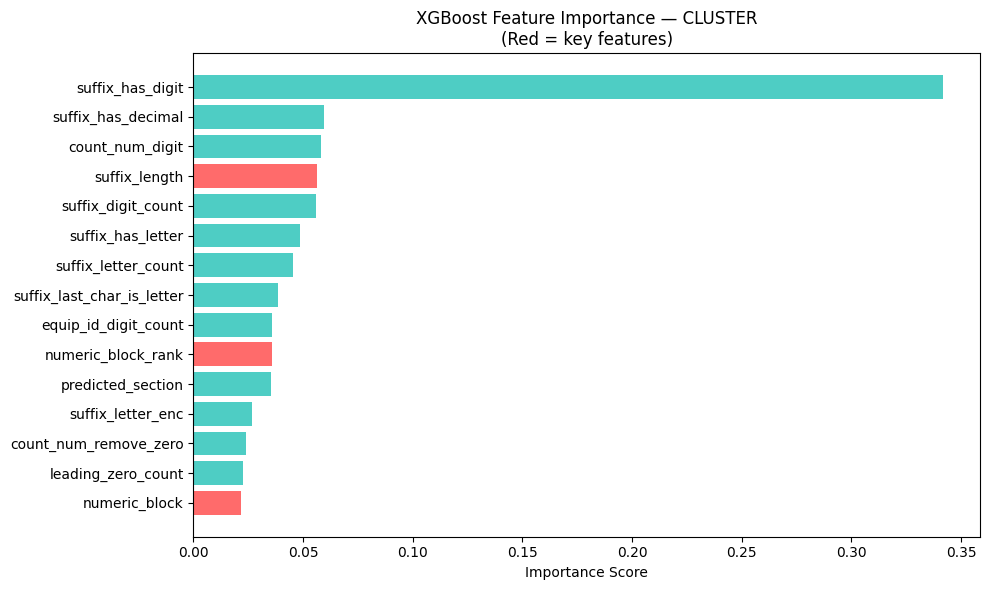

In [40]:

# ============================================================
# ⭐ FEATURE IMPORTANCE (ROBUST VERSION)
# ============================================================
print("\n" + "=" * 100)
print("⭐ FEATURE IMPORTANCE")
print("=" * 100)

key_features = [
    'numeric_block_rank',
    'suffix_last_char_enc',
    'suffix_length',
    'numeric_block'
]

# ✅ Map model → correct feature set
model_feature_map = {
    "SECTION": (model_section, X_train),
    "CLUSTER": (model_cluster, X_train_chained)  # ⚠ important
}

for label, (model, X_used) in model_feature_map.items():

    # ✅ Safety check
    if len(X_used.columns) != len(model.feature_importances_):
        print(f"⚠ Skipping {label}: feature mismatch")
        print(f"   Features: {len(X_used.columns)}, Importances: {len(model.feature_importances_)}")
        continue

    fi = pd.DataFrame({
        'feature'   : X_used.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"\n   [{label}]")
    print(fi.to_string(index=False))

    print(f"\n   Top 10 features for {label}:")
    print(fi.head(10).to_string(index=False))

    # 🎨 Color highlighting
    colors = [
        '#ff6b6b' if f in key_features else '#4ecdc4'
        for f in fi['feature']
    ]

    # 🎯 Plot only top 15 (cleaner)
    fi_top = fi.head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(fi_top['feature'], fi_top['importance'], color=colors[:len(fi_top)])
    plt.xlabel('Importance Score')
    plt.title(f'XGBoost Feature Importance — {label}\n(Red = key features)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()



# 9. Save Files

In [42]:
print("\n" + "=" * 100)
print("💾 SAVING MODEL AND ENCODERS")
print("=" * 100)

SAVE_DIR = r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\model_config"
os.makedirs(SAVE_DIR, exist_ok=True)

pickle.dump(model_section, open(os.path.join(SAVE_DIR, "model_section.pkl"), "wb"))
pickle.dump(model_cluster, open(os.path.join(SAVE_DIR, "model_cluster.pkl"), "wb"))

# Build known_customers directly from the training dataframe
known_customers = set(df['CUSTOMER'].astype(str).unique())

pipeline_config = {
    # Encoders (suffix-focused only)
    'le_suffix_letter'  : le_suffix_letter,
    'le_suffix_last'    : le_suffix_last,
    'le_section'        : le_section,
    'le_cluster'        : le_cluster,

    'feature_columns'   : feature_columns,
    'section_features'  : list(X_train.columns),
    'cluster_features'  : list(X_train_chained.columns),

    # Inference gate — stored separately, not fed into model
    'known_customers'   : known_customers,
    'key_features'      : key_features,
}

pickle.dump(pipeline_config, open(os.path.join(SAVE_DIR, "pipeline_config.pkl"), "wb"))
print("   ✅ Saved: model_section.pkl, model_cluster.pkl, pipeline_config.pkl")
print(f"   ✅ Known customers  : {sorted(known_customers)}")
print(f"   ✅ Section classes  : {[c for c in le_section.classes_ if c != '__UNKNOWN__']}")
print(f"   ✅ Cluster classes  : {[c for c in le_cluster.classes_ if c != '__UNKNOWN__']}")
print(f"   ✅ Total features   : {len(feature_columns)}")
print(f"   ✅ Section features : {len(list(X_train.columns))}")
print(f"   ✅ Cluster features : {len(list(X_train_chained.columns))}")


💾 SAVING MODEL AND ENCODERS
   ✅ Saved: model_section.pkl, model_cluster.pkl, pipeline_config.pkl
   ✅ Known customers  : ['OILTEK', 'UGS']
   ✅ Section classes  : [np.str_('SECTION 1'), np.str_('SECTION 2'), np.str_('SECTION 3'), np.str_('SECTION 4'), np.str_('SECTION 5'), np.str_('SECTION 6')]
   ✅ Cluster classes  : [np.str_('CLUSTER 1'), np.str_('CLUSTER 2'), np.str_('CLUSTER 3'), np.str_('CLUSTER 4'), np.str_('CLUSTER 5'), np.str_('CLUSTER 6'), np.str_('CLUSTER 7'), np.str_('CLUSTER 8'), np.str_('CLUSTER 9')]
   ✅ Total features   : 23
   ✅ Section features : 23
   ✅ Cluster features : 24


In [ ]:
# # ============================================================
# # 💾 SAVE (FULL PIPELINE SAFE) ------ delete soon
# # ============================================================


print("\n" + "=" * 100)
print("💾 SAVING MODEL AND ENCODERS")
print("=" * 100)

SAVE_DIR = r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\model_config"
os.makedirs(SAVE_DIR, exist_ok=True)

pickle.dump(model_section, open(os.path.join(SAVE_DIR, "model_section.pkl"), "wb"))
pickle.dump(model_cluster, open(os.path.join(SAVE_DIR, "model_cluster.pkl"), "wb"))

# Build known_customers directly from the training dataframe
known_customers = set(df['CUSTOMER'].astype(str).unique())

pipeline_config = {
    # Encoders (suffix-focused only)
    'le_suffix_letter'  : le_suffix_letter,
    'le_suffix_last'    : le_suffix_last,
    'le_section'        : le_section,
    'le_cluster'        : le_cluster,

    'feature_columns'   : feature_columns,
    'section_features'  : list(X_train.columns),
    'cluster_features'  : list(X_train_chained.columns),

    # Inference gate — stored separately, not fed into model
    'known_customers'   : known_customers,
    'key_features'      : key_features,
}

pickle.dump(pipeline_config, open(os.path.join(SAVE_DIR, "pipeline_config.pkl"), "wb"))
print("   ✅ Saved: model_section.pkl, model_cluster.pkl, pipeline_config.pkl")
print(f"   ✅ Known customers  : {sorted(known_customers)}")
print(f"   ✅ Section classes  : {list(le_section.real_classes())}")
print(f"   ✅ Cluster classes  : {list(le_cluster.real_classes())}")
print(f"   ✅ Total features   : {len(feature_columns)}")
print(f"   ✅ Section features : {len(list(X_train.columns))}")
print(f"   ✅ Cluster features : {len(list(X_train_chained.columns))}")

# --Finish --

### Save column [customer, project, device id, numeric block]

In [ ]:
df_oiltek_num = df[["CUSTOMER", "PROJECT", "SECTION", "CLUSTER", "DEVICE_ID", "numeric_block"]]
df_oiltek_num.to_pickle(
    r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\model_config\df_oiltek_num.pkl"
)

### to do next? <br>
cross tabulation distribution for result testing actual vs prediction ✅ <br>
suggestion to create chain model (2 xgboost model work heirarchy) ✅ <br>
removal suffix at the model ✅ <br>
REFINE NUMERICAL BLOCK ❓❌ <br>
<br>
**Check whether the model is run fix by customer?** ❓❌ <br>
<br>
<br>
**PROBLEM** : Model develope is not customer-specific. ❗❗❗ [23/4/2026] <br>
**SOLUTION** : `SafeLabelEncoder` (new class, drop-in replacement) — wraps sklearn's `LabelEncoder` and adds an `__UNKNOWN__` class at fit time. <br>
<br>
2 model = 2 model train and predict separately
chain model = 2 model train and linked the section and cluster
 <br>
 <br>
Inference checklist (application side): <br>
1. Load pipeline_config.pkl <br>
2. Load model_section.pkl and model_cluster.pkl <br>
3. Call predict_safe() — never call model.predict() directly <br>
4. If pred_section == 'UNKNOWN': the customer is not in the training set; do NOT surface a predicted cluster. <br>
5. To support a new customer: retrain with their data included and re-export pipeline_config.pkl <br>

## STOP HERE
TODAY
─────
1. Add width gate in check_entities()     ← blocks weird inputs now
2. Inject synthetic OOD rows              ← model learns to flag them
3. Retrain                                ← model now has the split node

ONGOING
───────
4. Log every blocked device               ← collect real OOD examples
5. Human labels them                      ← ground truth established
6. Add to training data                   ← replace synthetic with real
7. Retrain quarterly                      ← model improves over time

# New script 29/4/2026 - synthetic OOD injection

In [2]:
# %% [markdown]
# # 1. Load Function

# %%
import pandas as pd
import numpy as np
import re
import pickle
import os
import random
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# %% [markdown]
# # 2. Load Files

# %%
# ============================================================
# 📂 LOAD & COMBINE ALL PROJECT FILES
# ============================================================
print("=" * 100)
print("📊 LOADING DATA")
print("=" * 100)

folder_path = r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\dummy_data"

dfs = []
for file in os.listdir(folder_path):
    if file.endswith(".xlsx"):
        path = os.path.join(folder_path, file)
        try:
            df_temp = pd.read_excel(path)
            df_temp.columns = df_temp.columns.str.upper()
            dfs.append(df_temp)
            print(f"   ✅ Loaded: {file} — {len(df_temp)} rows")
        except Exception as e:
            print(f"   ⚠ Skipped ({e}): {file}")

if not dfs:
    raise ValueError("No Excel files found or loaded from the specified folder.")

df = pd.concat(dfs, ignore_index=True)

print(f"\n   Total records : {len(df)}")
print(f"   Columns       : {', '.join(df.columns)}")
print(f"\n📋 Preview:\n{df.head(10)}")


# %% [markdown]
# # Safe Label Encoder

# %%
class SafeLabelEncoder:
    """
    A LabelEncoder that:
      - Adds an '__UNKNOWN__' class during fit.
      - Returns the index of '__UNKNOWN__' for any unseen
        label during transform, instead of crashing.
      - Provides is_known(values) for explicit gate checks.

    Usage is identical to LabelEncoder:
        le = SafeLabelEncoder()
        le.fit(series)
        encoded = le.transform(series)
        decoded = le.inverse_transform(encoded_array)
    """

    UNKNOWN_LABEL = "__UNKNOWN__"

    # Set up the encoder and prepare an empty class list
    def __init__(self):
        self._le = LabelEncoder()
        self.classes_ = None

    # Learn all unique labels, reserving a slot for unknowns
    def fit(self, y):
        labels = list(pd.Series(y).astype(str).unique())
        if self.UNKNOWN_LABEL not in labels:
            labels = [self.UNKNOWN_LABEL] + labels
        self._le.fit(labels)
        self.classes_ = self._le.classes_
        return self

    # Encode labels, safely rerouting unseen values to __UNKNOWN__
    def transform(self, y):
        y_str = pd.Series(y).astype(str)
        known = set(self.classes_)
        y_safe = y_str.where(y_str.isin(known), other=self.UNKNOWN_LABEL)
        return self._le.transform(y_safe)

    # Fit and encode in one pass
    def fit_transform(self, y):
        return self.fit(y).transform(y)

    # Decode integers back to their original labels
    def inverse_transform(self, y):
        return self._le.inverse_transform(y)

    # Flag values unseen during training
    def is_known(self, values):
        """Return a boolean Series: True if value is known (not __UNKNOWN__)."""
        known = set(self.classes_) - {self.UNKNOWN_LABEL}
        return pd.Series(values).astype(str).isin(known)

    # Return real classes excluding the __UNKNOWN__ sentinel
    def real_classes(self):
        """Return classes excluding the __UNKNOWN__ sentinel."""
        return [c for c in self.classes_ if c != self.UNKNOWN_LABEL]


# %% [markdown]
# # 3. Feature Engineering

# %%
# script after removal prefixes extraction + numeric block convention features (28/4/2026)
print("\n" + "=" * 100)
print("🔧 FEATURE ENGINEERING  (suffix + numeric only — prefix excluded)")
print("=" * 100)

# Extract: first number found in the device ID (as integer — strips leading zeros)
def extract_numeric_block(device_id):
    match = re.search(r'\d+', str(device_id))
    return int(match.group()) if match else -1

# Extract: raw digit string preserving leading zeros  e.g. "051", "0000000021"
def extract_numeric_string(device_id):
    match = re.search(r'\d+', str(device_id))
    return match.group() if match else ''

# Extract: letters immediately after the trailing number
def extract_suffix_letters(device_id):
    match = re.search(r'\d+([A-Za-z]*)$', str(device_id))
    return match.group(1).upper() if match else ''

# Extract: everything after the trailing number
def extract_suffix_full(device_id):
    match = re.search(r'\d+(.*)$', str(device_id))
    return match.group(1) if match else ''

# Extract: numeric digits from a section string
def extract_section_num(section_str):
    digits = ''.join(c for c in str(section_str) if c.isdigit())
    return int(digits) if digits else 0

# Extract: numeric digits from a cluster string
def extract_cluster_num(cluster_str):
    digits = ''.join(c for c in str(cluster_str) if c.isdigit())
    return int(digits) if digits else 0

# ── Numeric block features ────────────────────────────────────
df['numeric_block']         = df['DEVICE_ID'].apply(extract_numeric_block)
df['device_suffix_letter']  = df['DEVICE_ID'].apply(extract_suffix_letters)
df['suffix_full']           = df['DEVICE_ID'].apply(extract_suffix_full)
df['device_id_length']      = df['DEVICE_ID'].astype(str).str.len()
df['has_suffix_letter']     = (df['device_suffix_letter'] != '').astype(int)
df['has_numeric']           = (df['numeric_block'] != -1).astype(int)

# ── Numeric block convention features ────────────────────────
print("\n   Creating numeric block convention features...")

_numeric_raw_str              = df['DEVICE_ID'].apply(extract_numeric_string)

# Total digit characters including leading zeros  e.g. "051"→3, "0000000021"→10
df['count_num_digit']         = _numeric_raw_str.str.len()

# Significant value after stripping leading zeros (same as numeric_block but explicit)
df['numeric_remove_zero']     = df['numeric_block']

# Digit count of the significant value  e.g. 51→2, 1→1, 21→2, 102837→6
df['count_num_remove_zero']   = df['numeric_remove_zero'].apply(
                                    lambda x: len(str(x)) if x != -1 else 0)

# Number of leading zeros = full width minus significant digit count
# e.g. "051"→1, "001"→2, "0000000021"→8  ← convention fingerprint
df['leading_zero_count']      = df['count_num_digit'] - df['count_num_remove_zero']

print("   ✅ Numeric block convention features created")

# ── Advanced suffix features ──────────────────────────────────
print("\n   Creating advanced suffix features...")

df['suffix_length']             = df['suffix_full'].astype(str).str.len()
df['suffix_has_digit']          = df['suffix_full'].astype(str).str.contains(r'\d', regex=True).astype(int)
df['suffix_has_letter']         = df['suffix_full'].astype(str).str.contains(r'[A-Za-z]', regex=True).astype(int)
df['suffix_has_decimal']        = df['suffix_full'].astype(str).str.contains(r'\.', regex=True).astype(int)
df['suffix_digit_count']        = df['suffix_full'].astype(str).str.count(r'\d')
df['suffix_letter_count']       = df['suffix_full'].astype(str).str.count(r'[A-Za-z]')
df['suffix_starts_with_digit']  = df['suffix_full'].astype(str).str[0].str.isdigit().fillna(0).astype(int)
df['suffix_last_char']          = df['suffix_full'].astype(str).str[-1]
df['suffix_last_char_is_letter']= df['suffix_last_char'].str.isalpha().fillna(0).astype(int)
df['suffix_last_char_is_digit'] = df['suffix_last_char'].str.isdigit().fillna(0).astype(int)

df['equip_id_length']           = df['DEVICE_ID'].astype(str).str.len()
df['equip_id_digit_count']      = df['DEVICE_ID'].astype(str).str.count(r'\d')

print("   ✅ Advanced suffix features created")

# ── Numeric block rank within project ────────────────────────
def assign_block_rank(group):
    unique_blocks = sorted(group['numeric_block'].unique())
    block_to_rank = {b: i + 1 for i, b in enumerate(unique_blocks)}
    return group['numeric_block'].map(block_to_rank)

df['numeric_block_rank'] = df.groupby(['CUSTOMER', 'PROJECT'], group_keys=False).apply(assign_block_rank)

print("   ✅ numeric_block_rank created")
print(f"\n   Sample feature preview:")
print(df[['CUSTOMER', 'PROJECT', 'DEVICE_ID',
          'numeric_block', 'count_num_digit', 'leading_zero_count',
          'count_num_remove_zero', 'suffix_full', 'suffix_last_char',
          'numeric_block_rank', 'SECTION']].head(15))


# %% [markdown]
# # 4. Label Encoding

# %%
print("\n" + "=" * 100)
print("🔤 ENCODING CATEGORICAL VARIABLES  (SafeLabelEncoder — suffix only)")
print("=" * 100)

le_suffix_letter  = SafeLabelEncoder()
le_suffix_last    = SafeLabelEncoder()
le_section        = SafeLabelEncoder()
le_cluster        = SafeLabelEncoder()

df['suffix_letter_enc']    = le_suffix_letter.fit_transform(df['device_suffix_letter'])
df['suffix_last_char_enc'] = le_suffix_last.fit_transform(df['suffix_last_char'])
df['section_enc']          = le_section.fit_transform(df['SECTION'])
df['cluster_enc']          = le_cluster.fit_transform(df['CLUSTER'])

print(f"   Section classes : {list(le_section.classes_)}")
print(f"   Cluster classes : {list(le_cluster.classes_)}")


📊 LOADING DATA
   ✅ Loaded: Oiltek_A1706.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9991.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9992.xlsx — 93 rows
   ✅ Loaded: Oiltek_A9993.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9994.xlsx — 108 rows
   ✅ Loaded: Oiltek_A9995.xlsx — 108 rows
   ✅ Loaded: UGS_A2027.xlsx — 328 rows
   ✅ Loaded: UGS_A8881.xlsx — 86 rows
   ✅ Loaded: UGS_A8882.xlsx — 115 rows
   ✅ Loaded: UGS_A8883.xlsx — 115 rows
   ✅ Loaded: UGS_A8884.xlsx — 115 rows
   ✅ Loaded: UGS_A8885.xlsx — 116 rows

   Total records : 1568
   Columns       : CUSTOMER, PROJECT, SECTION, CLUSTER, DEVICE_ID

📋 Preview:
  CUSTOMER PROJECT    SECTION    CLUSTER DEVICE_ID
0   OILTEK   A1706  SECTION 1  CLUSTER 1      A500
1   OILTEK   A1706  SECTION 1  CLUSTER 1     HT500
2   OILTEK   A1706  SECTION 1  CLUSTER 1    PT500A
3   OILTEK   A1706  SECTION 1  CLUSTER 1    PV500B
4   OILTEK   A1706  SECTION 1  CLUSTER 1     TE500
5   OILTEK   A1706  SECTION 2  CLUSTER 1    HLA600
6   OILTEK   A1706  SECTION 2  CLUSTER 1 

In [3]:


# %% [markdown]
# # 4b. Synthetic OOD Injection
#
# Purpose: Teach the model that wide numeric fields (unseen format)
# should map to a low-confidence / UNKNOWN outcome.
#
# Problem without this:
#   Training data only has count_num_digit = 3 (e.g. "051", "001").
#   XGBoost never builds a split on count_num_digit because it has
#   zero variance → feature is ignored → LL0000000021 (width=10)
#   gets routed to the default leaf → falsely high confidence.
#
# Solution:
#   Inject synthetic rows with wide numeric fields labeled __OOD__.
#   Now count_num_digit has variance across classes → XGBoost builds
#   the split → wide-field devices route to __OOD__ → low confidence.

# %%
print("\n" + "=" * 100)
print("🧪 INJECTING SYNTHETIC OUT-OF-DISTRIBUTION (OOD) ROWS")
print("=" * 100)

random.seed(42)

# ── Discover numeric width distribution BEFORE injection ─────
numeric_width_dist_real = (
    df['count_num_digit']
    .value_counts()
    .sort_index()
)

known_num_widths_real = set(df['count_num_digit'].unique())
max_num_width_real    = int(df['count_num_digit'].max())

# Reliable widths = widths that appear in at least 1% of real data
min_coverage     = max(1, int(len(df) * 0.01))
reliable_widths  = set(
    numeric_width_dist_real[numeric_width_dist_real >= min_coverage].index.tolist()
)

print(f"\n   Numeric field width distribution (real training data):")
print(numeric_width_dist_real.to_string())
print(f"\n   Known widths (all seen)      : {sorted(known_num_widths_real)}")
print(f"   Reliable widths (>= 1% data) : {sorted(reliable_widths)}")
print(f"   Max width seen               : {max_num_width_real}")


# ── Generate synthetic OOD device IDs ────────────────────────
def generate_ood_device_id(real_max_width, min_extra=4, max_extra=10):
    """
    Generate a device ID whose numeric field is WIDER than
    anything seen in real training data.

    min_extra / max_extra: how many extra digits beyond real_max_width
    to use. Default adds 4–10 extra digits, ensuring clear separation.
    """
    prefixes = ['XX', 'YY', 'ZZ', 'AA', 'BB']
    prefix   = random.choice(prefixes)
    n_digits = random.randint(
        real_max_width + min_extra,
        real_max_width + max_extra
    )
    # Random number zero-padded to n_digits
    number = str(random.randint(1, 10 ** max(1, n_digits - 2))).zfill(n_digits)
    return f"{prefix}{number}"


# How many synthetic rows to inject:
# 15% of the smallest real section class — enough to create variance
# without overwhelming the real signal.
n_real_min  = df['SECTION'].value_counts().min()
n_synthetic = max(50, int(n_real_min * 0.15))

# Use the first known customer and project as placeholders
# (customer/project are not model features — only used for block rank)
placeholder_customer = df['CUSTOMER'].iloc[0]
placeholder_project  = df['PROJECT'].iloc[0]

synthetic_rows = []
for _ in range(n_synthetic):
    synthetic_rows.append({
        'CUSTOMER'  : placeholder_customer,
        'PROJECT'   : placeholder_project,
        'DEVICE_ID' : generate_ood_device_id(max_num_width_real),
        'SECTION'   : '__OOD__',
        'CLUSTER'   : '__OOD__',
    })

df_synthetic = pd.DataFrame(synthetic_rows)

# ── Compute features for synthetic rows ──────────────────────
df_synthetic['numeric_block']        = df_synthetic['DEVICE_ID'].apply(extract_numeric_block)
df_synthetic['device_suffix_letter'] = df_synthetic['DEVICE_ID'].apply(extract_suffix_letters)
df_synthetic['suffix_full']          = df_synthetic['DEVICE_ID'].apply(extract_suffix_full)
df_synthetic['device_id_length']     = df_synthetic['DEVICE_ID'].astype(str).str.len()
df_synthetic['has_suffix_letter']    = (df_synthetic['device_suffix_letter'] != '').astype(int)
df_synthetic['has_numeric']          = (df_synthetic['numeric_block'] != -1).astype(int)

_syn_raw_str = df_synthetic['DEVICE_ID'].apply(extract_numeric_string)
df_synthetic['count_num_digit']       = _syn_raw_str.str.len()
df_synthetic['numeric_remove_zero']   = df_synthetic['numeric_block']
df_synthetic['count_num_remove_zero'] = df_synthetic['numeric_remove_zero'].apply(
                                            lambda x: len(str(x)) if x != -1 else 0)
df_synthetic['leading_zero_count']    = df_synthetic['count_num_digit'] - df_synthetic['count_num_remove_zero']

df_synthetic['suffix_length']            = df_synthetic['suffix_full'].astype(str).str.len()
df_synthetic['suffix_has_digit']         = df_synthetic['suffix_full'].astype(str).str.contains(r'\d',       regex=True).astype(int)
df_synthetic['suffix_has_letter']        = df_synthetic['suffix_full'].astype(str).str.contains(r'[A-Za-z]', regex=True).astype(int)
df_synthetic['suffix_has_decimal']       = df_synthetic['suffix_full'].astype(str).str.contains(r'\.',        regex=True).astype(int)
df_synthetic['suffix_digit_count']       = df_synthetic['suffix_full'].astype(str).str.count(r'\d')
df_synthetic['suffix_letter_count']      = df_synthetic['suffix_full'].astype(str).str.count(r'[A-Za-z]')

# ── Safe versions — avoid str[0] crash on empty suffix ───────
df_synthetic['suffix_starts_with_digit'] = df_synthetic['suffix_full'].apply(
                                               lambda s: 1 if len(str(s)) > 0 and str(s)[0].isdigit() else 0)
df_synthetic['suffix_last_char']         = df_synthetic['suffix_full'].apply(
                                               lambda s: str(s)[-1] if len(str(s)) > 0 else '')
df_synthetic['suffix_last_char_is_letter'] = df_synthetic['suffix_last_char'].apply(
                                                 lambda c: 1 if isinstance(c, str) and c.isalpha() else 0)
df_synthetic['suffix_last_char_is_digit']  = df_synthetic['suffix_last_char'].apply(
                                                 lambda c: 1 if isinstance(c, str) and c.isdigit() else 0)

df_synthetic['equip_id_length']      = df_synthetic['DEVICE_ID'].astype(str).str.len()
df_synthetic['equip_id_digit_count'] = df_synthetic['DEVICE_ID'].astype(str).str.count(r'\d')
df_synthetic['numeric_block_rank']   = 1

# ── Merge synthetic rows into main dataframe ──────────────────
df = pd.concat([df, df_synthetic], ignore_index=True)

print(f"\n   ✅ Injected {n_synthetic} synthetic OOD rows")
print(f"   ✅ New df shape          : {df.shape}")
print(f"\n   Numeric width distribution (real + OOD combined):")
print(df['count_num_digit'].value_counts().sort_index().to_string())
print(f"\n   Sample synthetic OOD rows:")
print(df_synthetic[['DEVICE_ID', 'count_num_digit', 'leading_zero_count', 'SECTION', 'CLUSTER']].head(8).to_string(index=False))




🧪 INJECTING SYNTHETIC OUT-OF-DISTRIBUTION (OOD) ROWS

   Numeric field width distribution (real training data):
count_num_digit
1    115
2    264
3    513
4    469
5    205
6      2

   Known widths (all seen)      : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
   Reliable widths (>= 1% data) : [1, 2, 3, 4, 5]
   Max width seen               : 6

   ✅ Injected 50 synthetic OOD rows
   ✅ New df shape          : (1618, 32)

   Numeric width distribution (real + OOD combined):
count_num_digit
1     115
2     264
3     513
4     469
5     205
6       2
10      7
11      4
12      7
13      9
14      6
15      7
16     10

   Sample synthetic OOD rows:
        DEVICE_ID  count_num_digit  leading_zero_count SECTION CLUSTER
     XX0099529224               10                   2 __OOD__ __OOD__
    ZZ00239670712               11                   2 __OOD__ __OOD__
YY001531350688821               15                   2 __OOD__ __OOD__
  BB0000136505588        

In [4]:
# %% [markdown]
# # 5. Features & Targets

# %%
feature_columns = [
    'DEVICE_ID',                  # traceability only — not fed to model

    # ── Numeric block: raw ───────────────────────────────────
    'numeric_block',              # significant integer value (leading zeros stripped)
    'numeric_block_rank',         # rank within project context

    # ── Numeric block: convention fingerprint ────────────────
    'count_num_digit',            # full field width incl. leading zeros  e.g. "051"→3
    'count_num_remove_zero',      # significant digit count               e.g. 51→2
    'numeric_remove_zero',        # significant value (explicit alias of numeric_block)
    'leading_zero_count',         # padding depth = convention identifier e.g. "051"→1

    # ── Device ID structural ─────────────────────────────────
    'device_id_length',
    'has_suffix_letter',
    'has_numeric',
    'equip_id_length',
    'equip_id_digit_count',

    # ── Suffix features ──────────────────────────────────────
    'suffix_letter_enc',
    'suffix_length',
    'suffix_has_digit',
    'suffix_has_letter',
    'suffix_has_decimal',
    'suffix_digit_count',
    'suffix_letter_count',
    'suffix_starts_with_digit',
    'suffix_last_char_enc',
    'suffix_last_char_is_letter',
    'suffix_last_char_is_digit',
]

X = df[feature_columns]
y_section = df['section_enc']
y_cluster = df['cluster_enc']

print(f"\n   Total features : {len(feature_columns)}")
print(f"   Feature list   : {feature_columns}")




   Total features : 23
   Feature list   : ['DEVICE_ID', 'numeric_block', 'numeric_block_rank', 'count_num_digit', 'count_num_remove_zero', 'numeric_remove_zero', 'leading_zero_count', 'device_id_length', 'has_suffix_letter', 'has_numeric', 'equip_id_length', 'equip_id_digit_count', 'suffix_letter_enc', 'suffix_length', 'suffix_has_digit', 'suffix_has_letter', 'suffix_has_decimal', 'suffix_digit_count', 'suffix_letter_count', 'suffix_starts_with_digit', 'suffix_last_char_enc', 'suffix_last_char_is_letter', 'suffix_last_char_is_digit']


In [6]:
# %% [markdown]
# # 6. Chain Model (Train, Val, Test)

# %%
# ============================================================
# ✂️ TRAIN / VAL / TEST SPLIT (DataFrame-based)
# ============================================================
print("\n" + "=" * 100)
print("✂️  SPLITTING DATA")
print("=" * 100)

# ── Diagnostics: check for NaN in targets before split ───────
print("\n   Pre-split target diagnostics:")
print(f"   y_section NaN count : {y_section.isna().sum()}")
print(f"   y_cluster  NaN count : {y_cluster.isna().sum()}")

if y_section.isna().sum() > 0:
    print("\n   ⚠ Rows with NaN in section_enc:")
    print(df[y_section.isna()][['DEVICE_ID', 'SECTION', 'section_enc']].head(10))

if y_cluster.isna().sum() > 0:
    print("\n   ⚠ Rows with NaN in cluster_enc:")
    print(df[y_cluster.isna()][['DEVICE_ID', 'CLUSTER', 'cluster_enc']].head(10))

# ── Force cast targets to int — prevents NaN from dtype mismatch
# pd.concat can promote int64 → float64 when dtypes differ between
# real and synthetic rows, introducing NaN. Explicit cast fixes this.
y_section = y_section.fillna(
    le_section.transform(['__UNKNOWN__'])[0]
).astype(int)

y_cluster = y_cluster.fillna(
    le_cluster.transform(['__UNKNOWN__'])[0]
).astype(int)

print(f"\n   After NaN fill:")
print(f"   y_section NaN count : {y_section.isna().sum()}  ✅")
print(f"   y_cluster  NaN count : {y_cluster.isna().sum()}  ✅")
print(f"   y_section unique values : {sorted(y_section.unique())}")
print(f"   y_cluster  unique values : {sorted(y_cluster.unique())}")


def safe_split_df(df, label_col, test_size=0.15, val_size=0.176, max_attempts=100):
    y = df[label_col]
    all_classes = set(np.unique(y))

    for attempt in range(max_attempts):
        idx_tmp, idx_test = train_test_split(
            df.index,
            test_size=test_size,
            random_state=42 + attempt,
            stratify=y,
            shuffle=True
        )
        idx_train, idx_val = train_test_split(
            idx_tmp,
            test_size=val_size,
            random_state=42 + attempt,
            stratify=y.loc[idx_tmp],
            shuffle=True
        )
        if set(np.unique(y.loc[idx_train])) == all_classes:
            print(f"   ✅ Valid split on attempt {attempt + 1}")
            break
    else:
        print("   ⚠ Using last split (not all classes in train)")

    train_df = df.loc[idx_train].copy().reset_index(drop=False)
    val_df   = df.loc[idx_val].copy().reset_index(drop=False)
    test_df  = df.loc[idx_test].copy().reset_index(drop=False)

    train_df["_split"] = "train"
    val_df["_split"]   = "val"
    test_df["_split"]  = "test"

    return train_df, val_df, test_df


full_df              = X.copy()
full_df["y_section"] = y_section.values   # .values avoids index mismatch after reset
full_df["y_cluster"] = y_cluster.values

train_df, val_df, test_df = safe_split_df(full_df, label_col="y_section")

feature_cols = X.columns.tolist()


def extract_features(df, cols):
    X_out = df[cols].apply(pd.to_numeric, errors='coerce')
    bad   = X_out.dtypes[X_out.dtypes == 'object'].index.tolist()
    if bad:
        print(f"   ⚠ Dropping non-numeric columns: {bad}")
        X_out = X_out.drop(columns=bad)
    return X_out.fillna(0)


X_train = extract_features(train_df, feature_cols)
X_val   = extract_features(val_df,   feature_cols)
X_test  = extract_features(test_df,  feature_cols)

y_sec_train = train_df["y_section"].astype(int)
y_sec_val   = val_df["y_section"].astype(int)
y_sec_test  = test_df["y_section"].astype(int)

y_clu_train = train_df["y_cluster"].astype(int)
y_clu_val   = val_df["y_cluster"].astype(int)
y_clu_test  = test_df["y_cluster"].astype(int)

print(f"\n   Train : {len(train_df):,} rows")
print(f"   Val   : {len(val_df):,} rows")
print(f"   Test  : {len(test_df):,} rows")
print(f"   Feature shape (train) : {X_train.shape}")

# ── Verify no NaN leaked into splits ─────────────────────────
for name, y in [("y_sec_train", y_sec_train), ("y_sec_val", y_sec_val),
                ("y_sec_test",  y_sec_test),  ("y_clu_train", y_clu_train),
                ("y_clu_val",   y_clu_val),   ("y_clu_test",  y_clu_test)]:
    n_nan = y.isna().sum()
    status = "✅" if n_nan == 0 else f"⚠ {n_nan} NaN found"
    print(f"   {name:15s} : {status}")


✂️  SPLITTING DATA

   Pre-split target diagnostics:
   y_section NaN count : 50
   y_cluster  NaN count : 50

   ⚠ Rows with NaN in section_enc:
               DEVICE_ID  SECTION  section_enc
1568        XX0099529224  __OOD__          NaN
1569       ZZ00239670712  __OOD__          NaN
1570   YY001531350688821  __OOD__          NaN
1571     BB0000136505588  __OOD__          NaN
1572       XX00249817735  __OOD__          NaN
1573    BB00614294294452  __OOD__          NaN
1574   YY007381094320375  __OOD__          NaN
1575     YY0036890615213  __OOD__          NaN
1576  XX0022470434892734  __OOD__          NaN
1577      AA001193448330  __OOD__          NaN

   ⚠ Rows with NaN in cluster_enc:
               DEVICE_ID  CLUSTER  cluster_enc
1568        XX0099529224  __OOD__          NaN
1569       ZZ00239670712  __OOD__          NaN
1570   YY001531350688821  __OOD__          NaN
1571     BB0000136505588  __OOD__          NaN
1572       XX00249817735  __OOD__          NaN
1573    BB00614294

In [7]:

# ============================================================
# 🚀 STAGE 1 — SECTION MODEL
# ============================================================
print("\n" + "=" * 100)
print("🚀 STAGE 1 — TRAINING SECTION MODEL")
print("=" * 100)


def build_model(n_classes):
    return xgb.XGBClassifier(
        objective        = 'multi:softprob',
        num_class        = n_classes,
        max_depth        = 6,
        learning_rate    = 0.05,
        n_estimators     = 300,
        min_child_weight = 1,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        gamma            = 0.1,
        random_state     = 42,
        eval_metric      = 'mlogloss',
    )


# Exclude __UNKNOWN__ from class count — it is a SafeLabelEncoder sentinel,
# not a real training class. Passing len(le.classes_) directly would give
# XGBoost the wrong num_class and cause a mismatch downstream.
n_section_classes = sum(1 for c in le_section.classes_ if c != "__UNKNOWN__")
n_cluster_classes = sum(1 for c in le_cluster.classes_ if c != "__UNKNOWN__")

model_section = build_model(n_section_classes)
model_section.fit(
    X_train, y_sec_train,
    eval_set=[(X_train, y_sec_train), (X_val, y_sec_val)],
    verbose=False
)

y_sec_pred_train = model_section.predict(X_train)
y_sec_pred_val   = model_section.predict(X_val)
y_sec_pred_test  = model_section.predict(X_test)

print(f"\n   🎯 Section Test Accuracy: {accuracy_score(y_sec_test, y_sec_pred_test):.2%}")

sec_labels = sorted(set(y_sec_test) | set(y_sec_pred_test))
print(classification_report(
    y_sec_test, y_sec_pred_test,
    labels=sec_labels,
    target_names=[le_section.classes_[i] for i in sec_labels],
    zero_division=0
))


# ============================================================
# 🔗 CHAIN — INJECT SECTION PREDICTION INTO CLUSTER FEATURES
# ============================================================
print("\n" + "=" * 100)
print("🔗 CHAINING — INJECTING SECTION PREDICTION INTO CLUSTER FEATURES")
print("=" * 100)

X_train_chained = X_train.copy()
X_val_chained   = X_val.copy()
X_test_chained  = X_test.copy()

X_train_chained["predicted_section"] = y_sec_pred_train
X_val_chained["predicted_section"]   = y_sec_pred_val
X_test_chained["predicted_section"]  = y_sec_pred_test

print(f"   ✅ Feature shape after chaining: {X_train_chained.shape}")


# ============================================================
# 🚀 STAGE 2 — CLUSTER MODEL
# ============================================================
print("\n" + "=" * 100)
print("🚀 STAGE 2 — TRAINING CLUSTER MODEL")
print("=" * 100)

model_cluster = build_model(n_cluster_classes)
model_cluster.fit(
    X_train_chained, y_clu_train,
    eval_set=[(X_train_chained, y_clu_train), (X_val_chained, y_clu_val)],
    verbose=False
)

y_clu_pred = model_cluster.predict(X_test_chained)

print(f"\n   🎯 Cluster Test Accuracy: {accuracy_score(y_clu_test, y_clu_pred):.2%}")

clu_labels = sorted(set(y_clu_test) | set(y_clu_pred))
print(classification_report(
    y_clu_test, y_clu_pred,
    labels=clu_labels,
    target_names=[le_cluster.classes_[i] for i in clu_labels],
    zero_division=0
))


# ============================================================
# 📋 CHAIN SUMMARY
# ============================================================
print("\n" + "=" * 100)
print("📋 CHAINED MODEL SUMMARY")
print("=" * 100)
print(f"   Stage 1 — Section Model : {accuracy_score(y_sec_test, y_sec_pred_test):.2%} accuracy")
print(f"   Stage 2 — Cluster Model : {accuracy_score(y_clu_test, y_clu_pred):.2%} accuracy")
print(f"\n   Chain flow:")
print(f"      X_features → [Section Model] → predicted_section")
print(f"      X_features + predicted_section → [Cluster Model] → predicted_cluster")


# %% [markdown]
# # 7. Chain Model Output

# %%
# ============================================================
# 📋 RESULT DATAFRAME — CHAINED MODEL PREDICTIONS
# ============================================================

# ✅ TRAIN
train_df2 = train_df[["index", "DEVICE_ID", "y_section", "y_cluster", "_split"]].copy()
train_df2["actual_section"]    = le_section.inverse_transform(train_df2["y_section"])
train_df2["actual_cluster"]    = le_cluster.inverse_transform(train_df2["y_cluster"])
train_df2["pred_section"]      = le_section.inverse_transform(y_sec_pred_train)
train_df2["pred_cluster"]      = le_cluster.inverse_transform(model_cluster.predict(X_train_chained))
train_df2["section_correct"]   = train_df2["actual_section"] == train_df2["pred_section"]
train_df2["cluster_correct"]   = train_df2["actual_cluster"] == train_df2["pred_cluster"]

# ✅ VAL
val_df2 = val_df[["index", "DEVICE_ID", "y_section", "y_cluster", "_split"]].copy()
val_df2["actual_section"]      = le_section.inverse_transform(val_df2["y_section"])
val_df2["actual_cluster"]      = le_cluster.inverse_transform(val_df2["y_cluster"])
val_df2["pred_section"]        = le_section.inverse_transform(y_sec_pred_val)
val_df2["pred_cluster"]        = le_cluster.inverse_transform(model_cluster.predict(X_val_chained))
val_df2["section_correct"]     = val_df2["actual_section"] == val_df2["pred_section"]
val_df2["cluster_correct"]     = val_df2["actual_cluster"] == val_df2["pred_cluster"]

# ✅ TEST
test_df2 = test_df[["index", "DEVICE_ID", "y_section", "y_cluster", "_split"]].copy()
test_df2["actual_section"]     = le_section.inverse_transform(test_df2["y_section"])
test_df2["actual_cluster"]     = le_cluster.inverse_transform(test_df2["y_cluster"])
test_df2["pred_section"]       = le_section.inverse_transform(y_sec_pred_test)
test_df2["pred_cluster"]       = le_cluster.inverse_transform(y_clu_pred)
test_df2["section_correct"]    = test_df2["actual_section"] == test_df2["pred_section"]
test_df2["cluster_correct"]    = test_df2["actual_cluster"] == test_df2["pred_cluster"]

# ✅ COMBINE ALL SPLITS
full_result_df = pd.concat([train_df2, val_df2, test_df2], ignore_index=True)

# ✅ DIAGNOSTICS
print("\n" + "=" * 100)
print("📋 PREDICTION RESULT SUMMARY")
print("=" * 100)

for split_name, df_split in [("TRAIN", train_df2), ("VAL", val_df2), ("TEST", test_df2)]:
    sec_acc = df_split["section_correct"].mean()
    clu_acc = df_split["cluster_correct"].mean()
    print(f"\n   [{split_name}]")
    print(f"      Section Accuracy : {sec_acc:.2%}")
    print(f"      Cluster Accuracy : {clu_acc:.2%}")

print(f"\n   📊 Full result shape : {full_result_df.shape}")

# %%
# ============================================================
# 📊 FORMATTED RESULT TABLE (SECTION + CLUSTER CHECK)
# ============================================================

result_df = test_df[["DEVICE_ID"]].copy()

result_df["Actual Section"]    = le_section.inverse_transform(y_sec_test)
result_df["Predicted Section"] = le_section.inverse_transform(y_sec_pred_test)
result_df["Check Section"]     = result_df["Actual Section"] == result_df["Predicted Section"]

result_df["Actual Cluster"]    = le_cluster.inverse_transform(y_clu_test)
result_df["Predicted Cluster"] = le_cluster.inverse_transform(y_clu_pred)
result_df["Check Cluster"]     = result_df["Actual Cluster"] == result_df["Predicted Cluster"]

def format_check(val):
    return "✅ True" if val else "❌ False"

result_df["Check Section"] = result_df["Check Section"].apply(format_check)
result_df["Check Cluster"] = result_df["Check Cluster"].apply(format_check)

print("\n📊 FORMATTED RESULT TABLE")
print("=" * 100)
pd.set_option('display.max_rows', None)
print(result_df)




🚀 STAGE 1 — TRAINING SECTION MODEL

   🎯 Section Test Accuracy: 98.77%
              precision    recall  f1-score   support

   SECTION 1       0.97      1.00      0.99        71
   SECTION 2       1.00      0.98      0.99        54
   SECTION 3       1.00      0.98      0.99        45
   SECTION 4       0.96      1.00      0.98        23
   SECTION 5       1.00      1.00      1.00        38
   SECTION 6       1.00      0.75      0.86         4
 __UNKNOWN__       1.00      1.00      1.00         8

    accuracy                           0.99       243
   macro avg       0.99      0.96      0.97       243
weighted avg       0.99      0.99      0.99       243


🔗 CHAINING — INJECTING SECTION PREDICTION INTO CLUSTER FEATURES
   ✅ Feature shape after chaining: (1133, 24)

🚀 STAGE 2 — TRAINING CLUSTER MODEL

   🎯 Cluster Test Accuracy: 96.71%
              precision    recall  f1-score   support

   CLUSTER 1       0.99      0.99      0.99        92
   CLUSTER 2       1.00      0.94      


⭐ FEATURE IMPORTANCE

   [SECTION]
                   feature  importance
         suffix_has_letter    0.324478
        suffix_has_decimal    0.151159
      equip_id_digit_count    0.144277
           count_num_digit    0.090715
       suffix_letter_count    0.044777
          suffix_has_digit    0.034543
       numeric_remove_zero    0.031724
             numeric_block    0.027235
     count_num_remove_zero    0.025247
             suffix_length    0.023006
      suffix_last_char_enc    0.021387
        leading_zero_count    0.020218
           equip_id_length    0.018663
        numeric_block_rank    0.013158
          device_id_length    0.010046
         suffix_letter_enc    0.006585
        suffix_digit_count    0.006510
         has_suffix_letter    0.005366
suffix_last_char_is_letter    0.000907
                 DEVICE_ID    0.000000
               has_numeric    0.000000
  suffix_starts_with_digit    0.000000
 suffix_last_char_is_digit    0.000000

   Top 10 features for SECT

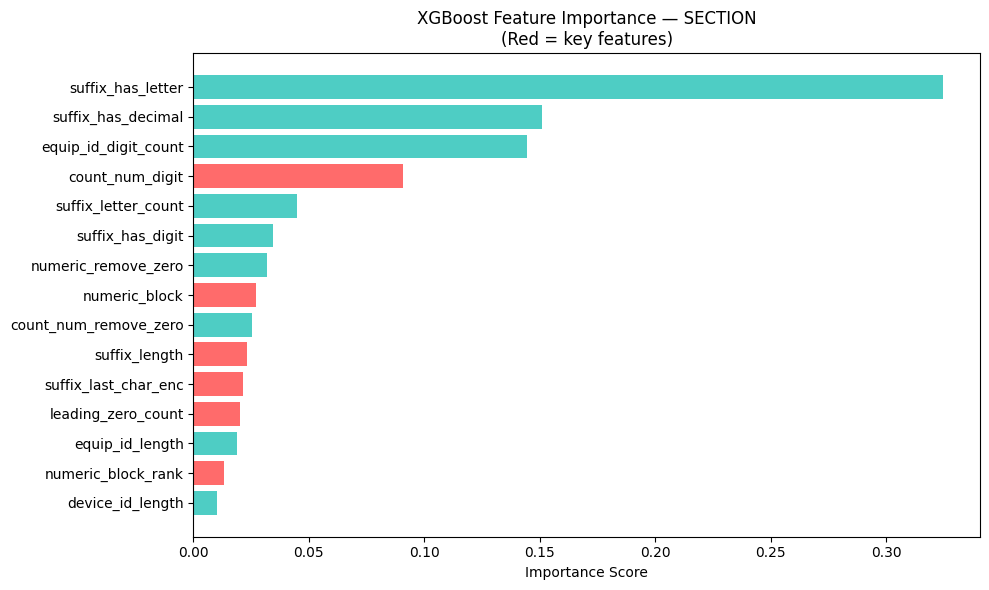


   [CLUSTER]
                   feature  importance
          suffix_has_digit    0.220970
           count_num_digit    0.090609
     count_num_remove_zero    0.070065
        suffix_has_decimal    0.069151
      equip_id_digit_count    0.062635
             suffix_length    0.056648
        suffix_digit_count    0.051992
         suffix_has_letter    0.049660
 suffix_last_char_is_digit    0.042123
         predicted_section    0.036999
         suffix_letter_enc    0.034350
        numeric_block_rank    0.032514
       suffix_letter_count    0.031522
        leading_zero_count    0.028460
          device_id_length    0.022532
             numeric_block    0.021921
         has_suffix_letter    0.019605
           equip_id_length    0.019142
       numeric_remove_zero    0.016889
      suffix_last_char_enc    0.013210
suffix_last_char_is_letter    0.009002
                 DEVICE_ID    0.000000
               has_numeric    0.000000
  suffix_starts_with_digit    0.000000

   Top 10 

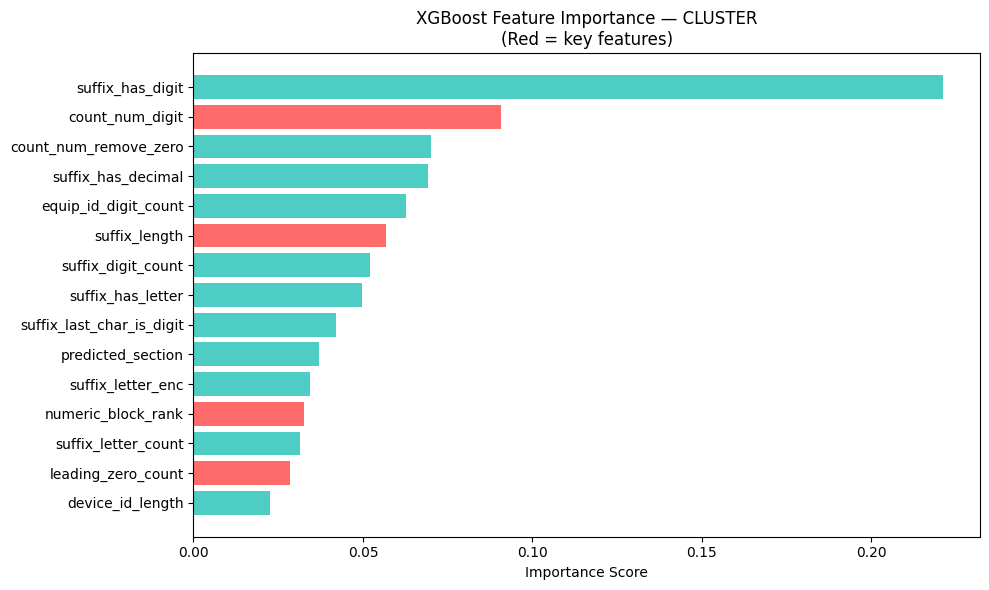


💾 SAVING MODEL AND ENCODERS

   Numeric width knowledge (from real training data):
      known_num_widths  : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
      reliable_widths   : [1, 2, 3, 4, 5]
      max_num_width     : 6

   ✅ Saved: model_section.pkl, model_cluster.pkl, pipeline_config.pkl
   ✅ Known customers   : ['OILTEK', 'UGS']
   ✅ Section classes   : [np.str_('SECTION 1'), np.str_('SECTION 2'), np.str_('SECTION 3'), np.str_('SECTION 4'), np.str_('SECTION 5'), np.str_('SECTION 6')]
   ✅ Cluster classes   : [np.str_('CLUSTER 1'), np.str_('CLUSTER 2'), np.str_('CLUSTER 3'), np.str_('CLUSTER 4'), np.str_('CLUSTER 5'), np.str_('CLUSTER 6'), np.str_('CLUSTER 7'), np.str_('CLUSTER 8'), np.str_('CLUSTER 9')]
   ✅ Total features    : 23
   ✅ Section features  : 23
   ✅ Cluster features  : 24
   ✅ OOD rows injected : 50
   ✅ Max num width     : 6 digits (real data)


In [8]:

# %% [markdown]
# # 8. Feature Importance

# %%
# ============================================================
# ⭐ FEATURE IMPORTANCE (ROBUST VERSION)
# ============================================================
print("\n" + "=" * 100)
print("⭐ FEATURE IMPORTANCE")
print("=" * 100)

key_features = [
    'numeric_block_rank',
    'suffix_last_char_enc',
    'suffix_length',
    'numeric_block',
    'count_num_digit',        # ← new key feature
    'leading_zero_count',     # ← new key feature
]

model_feature_map = {
    "SECTION": (model_section, X_train),
    "CLUSTER": (model_cluster, X_train_chained)
}

for label, (model, X_used) in model_feature_map.items():

    if len(X_used.columns) != len(model.feature_importances_):
        print(f"⚠ Skipping {label}: feature mismatch")
        print(f"   Features: {len(X_used.columns)}, Importances: {len(model.feature_importances_)}")
        continue

    fi = pd.DataFrame({
        'feature'   : X_used.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"\n   [{label}]")
    print(fi.to_string(index=False))

    print(f"\n   Top 10 features for {label}:")
    print(fi.head(10).to_string(index=False))

    # Check if OOD features are contributing
    ood_features = ['count_num_digit', 'leading_zero_count', 'count_num_remove_zero']
    print(f"\n   OOD feature importance:")
    for f in ood_features:
        if f in fi['feature'].values:
            imp = fi.loc[fi['feature'] == f, 'importance'].values[0]
            status = "✅ active" if imp > 0.001 else "⚠️  near-zero"
            print(f"      {f:30s} : {imp:.6f}  {status}")

    colors = [
        '#ff6b6b' if f in key_features else '#4ecdc4'
        for f in fi['feature']
    ]

    fi_top = fi.head(15)
    plt.figure(figsize=(10, 6))
    plt.barh(fi_top['feature'], fi_top['importance'], color=colors[:len(fi_top)])
    plt.xlabel('Importance Score')
    plt.title(f'XGBoost Feature Importance — {label}\n(Red = key features)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


# %% [markdown]
# # 9. Save Files

# %%
print("\n" + "=" * 100)
print("💾 SAVING MODEL AND ENCODERS")
print("=" * 100)

SAVE_DIR = r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\model_config"
os.makedirs(SAVE_DIR, exist_ok=True)

pickle.dump(model_section, open(os.path.join(SAVE_DIR, "model_section.pkl"), "wb"))
pickle.dump(model_cluster, open(os.path.join(SAVE_DIR, "model_cluster.pkl"), "wb"))

# ── Build known_customers from training data ──────────────────
known_customers = set(
    c for c in df['CUSTOMER'].astype(str).unique()
    if c not in ('__OOD__',)      # exclude synthetic placeholder if any
)

# ── Numeric width knowledge — data-driven, not hardcoded ─────
# Computed from REAL data only (before OOD injection) so the
# gate reflects actual project naming conventions.
#
#   known_num_widths  : every width seen in real data
#   reliable_widths   : widths with >= 1% coverage (trusted)
#   max_num_width     : hard ceiling — anything above is OOD
#
# These are saved into pipeline_config and used by check_entities()
# in the application script to gate inference before model sees input.

print(f"\n   Numeric width knowledge (from real training data):")
print(f"      known_num_widths  : {sorted(known_num_widths_real)}")
print(f"      reliable_widths   : {sorted(reliable_widths)}")
print(f"      max_num_width     : {max_num_width_real}")

pipeline_config = {
    # ── Encoders (suffix-focused only) ───────────────────────
    'le_suffix_letter'  : le_suffix_letter,
    'le_suffix_last'    : le_suffix_last,
    'le_section'        : le_section,
    'le_cluster'        : le_cluster,

    # ── Feature lists ────────────────────────────────────────
    'feature_columns'   : feature_columns,
    'section_features'  : list(X_train.columns),
    'cluster_features'  : list(X_train_chained.columns),

    # ── Inference gate: customer ─────────────────────────────
    'known_customers'   : known_customers,

    # ── Inference gate: numeric width (data-driven) ──────────
    'known_num_widths'  : known_num_widths_real,   # all widths seen in real data
    'reliable_widths'   : reliable_widths,          # widths with >= 1% coverage
    'max_num_width'     : max_num_width_real,       # hard ceiling

    # ── Feature importance reference ─────────────────────────
    'key_features'      : key_features,
}

pickle.dump(pipeline_config, open(os.path.join(SAVE_DIR, "pipeline_config.pkl"), "wb"))

print("\n   ✅ Saved: model_section.pkl, model_cluster.pkl, pipeline_config.pkl")
print(f"   ✅ Known customers   : {sorted(known_customers)}")
print(f"   ✅ Section classes   : {le_section.real_classes()}")
print(f"   ✅ Cluster classes   : {le_cluster.real_classes()}")
print(f"   ✅ Total features    : {len(feature_columns)}")
print(f"   ✅ Section features  : {len(list(X_train.columns))}")
print(f"   ✅ Cluster features  : {len(list(X_train_chained.columns))}")
print(f"   ✅ OOD rows injected : {n_synthetic}")
print(f"   ✅ Max num width     : {max_num_width_real} digits (real data)")

# script 2.0 - integrate KNN

In [ ]:
# %% [markdown]
# # 1. Load Function

# %%
import pandas as pd
import numpy as np
import re
import pickle
import os
import random
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# %% [markdown]
# # 2. Load Files

# %%
# ============================================================
# 📂 LOAD & COMBINE ALL PROJECT FILES
# ============================================================
print("=" * 100)
print("📊 LOADING DATA")
print("=" * 100)

folder_path = r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\dummy_data"

dfs = []
for file in os.listdir(folder_path):
    if file.endswith(".xlsx"):
        path = os.path.join(folder_path, file)
        try:
            df_temp = pd.read_excel(path)
            df_temp.columns = df_temp.columns.str.upper()
            dfs.append(df_temp)
            print(f"   ✅ Loaded: {file} — {len(df_temp)} rows")
        except Exception as e:
            print(f"   ⚠ Skipped ({e}): {file}")

if not dfs:
    raise ValueError("No Excel files found or loaded from the specified folder.")

df = pd.concat(dfs, ignore_index=True)

print(f"\n   Total records : {len(df)}")
print(f"   Columns       : {', '.join(df.columns)}")
print(f"\n📋 Preview:\n{df.head(10)}")


# %% [markdown]
# # Safe Label Encoder

# %%
class SafeLabelEncoder:
    """
    A LabelEncoder that:
      - Adds an '__UNKNOWN__' class during fit.
      - Returns the index of '__UNKNOWN__' for any unseen
        label during transform, instead of crashing.
      - Provides is_known(values) for explicit gate checks.

    Usage is identical to LabelEncoder:
        le = SafeLabelEncoder()
        le.fit(series)
        encoded = le.transform(series)
        decoded = le.inverse_transform(encoded_array)
    """

    UNKNOWN_LABEL = "__UNKNOWN__"

    # Set up the encoder and prepare an empty class list
    def __init__(self):
        self._le = LabelEncoder()
        self.classes_ = None

    # Learn all unique labels, reserving a slot for unknowns
    def fit(self, y):
        labels = list(pd.Series(y).astype(str).unique())
        if self.UNKNOWN_LABEL not in labels:
            labels = [self.UNKNOWN_LABEL] + labels
        self._le.fit(labels)
        self.classes_ = self._le.classes_
        return self

    # Encode labels, safely rerouting unseen values to __UNKNOWN__
    def transform(self, y):
        y_str = pd.Series(y).astype(str)
        known = set(self.classes_)
        y_safe = y_str.where(y_str.isin(known), other=self.UNKNOWN_LABEL)
        return self._le.transform(y_safe)

    # Fit and encode in one pass
    def fit_transform(self, y):
        return self.fit(y).transform(y)

    # Decode integers back to their original labels
    def inverse_transform(self, y):
        return self._le.inverse_transform(y)

    # Flag values unseen during training
    def is_known(self, values):
        """Return a boolean Series: True if value is known (not __UNKNOWN__)."""
        known = set(self.classes_) - {self.UNKNOWN_LABEL}
        return pd.Series(values).astype(str).isin(known)

    # Return real classes excluding the __UNKNOWN__ sentinel
    def real_classes(self):
        """Return classes excluding the __UNKNOWN__ sentinel."""
        return [c for c in self.classes_ if c != self.UNKNOWN_LABEL]


# %% [markdown]
# # 3. Feature Engineering

# %%
# script after removal prefixes extraction + numeric block convention features (28/4/2026)
print("\n" + "=" * 100)
print("🔧 FEATURE ENGINEERING  (suffix + numeric only — prefix excluded)")
print("=" * 100)

# Extract: first number found in the device ID (as integer — strips leading zeros)
def extract_numeric_block(device_id):
    match = re.search(r'\d+', str(device_id))
    return int(match.group()) if match else -1

# Extract: raw digit string preserving leading zeros  e.g. "051", "0000000021"
def extract_numeric_string(device_id):
    match = re.search(r'\d+', str(device_id))
    return match.group() if match else ''

# Extract: letters immediately after the trailing number
def extract_suffix_letters(device_id):
    match = re.search(r'\d+([A-Za-z]*)$', str(device_id))
    return match.group(1).upper() if match else ''

# Extract: everything after the trailing number
def extract_suffix_full(device_id):
    match = re.search(r'\d+(.*)$', str(device_id))
    return match.group(1) if match else ''

# Extract: numeric digits from a section string
def extract_section_num(section_str):
    digits = ''.join(c for c in str(section_str) if c.isdigit())
    return int(digits) if digits else 0

# Extract: numeric digits from a cluster string
def extract_cluster_num(cluster_str):
    digits = ''.join(c for c in str(cluster_str) if c.isdigit())
    return int(digits) if digits else 0

# ── Numeric block features ────────────────────────────────────
df['numeric_block']         = df['DEVICE_ID'].apply(extract_numeric_block)
df['device_suffix_letter']  = df['DEVICE_ID'].apply(extract_suffix_letters)
df['suffix_full']           = df['DEVICE_ID'].apply(extract_suffix_full)
df['device_id_length']      = df['DEVICE_ID'].astype(str).str.len()
df['has_suffix_letter']     = (df['device_suffix_letter'] != '').astype(int)
df['has_numeric']           = (df['numeric_block'] != -1).astype(int)

# ── Numeric block convention features ────────────────────────
print("\n   Creating numeric block convention features...")

_numeric_raw_str              = df['DEVICE_ID'].apply(extract_numeric_string)

# Total digit characters including leading zeros  e.g. "051"→3, "0000000021"→10
df['count_num_digit']         = _numeric_raw_str.str.len()

# Significant value after stripping leading zeros (same as numeric_block but explicit)
df['numeric_remove_zero']     = df['numeric_block']

# Digit count of the significant value  e.g. 51→2, 1→1, 21→2, 102837→6
df['count_num_remove_zero']   = df['numeric_remove_zero'].apply(
                                    lambda x: len(str(x)) if x != -1 else 0)

# Number of leading zeros = full width minus significant digit count
# e.g. "051"→1, "001"→2, "0000000021"→8  ← convention fingerprint
df['leading_zero_count']      = df['count_num_digit'] - df['count_num_remove_zero']

print("   ✅ Numeric block convention features created")

# ── Advanced suffix features ──────────────────────────────────
print("\n   Creating advanced suffix features...")

df['suffix_length']             = df['suffix_full'].astype(str).str.len()
df['suffix_has_digit']          = df['suffix_full'].astype(str).str.contains(r'\d', regex=True).astype(int)
df['suffix_has_letter']         = df['suffix_full'].astype(str).str.contains(r'[A-Za-z]', regex=True).astype(int)
df['suffix_has_decimal']        = df['suffix_full'].astype(str).str.contains(r'\.', regex=True).astype(int)
df['suffix_digit_count']        = df['suffix_full'].astype(str).str.count(r'\d')
df['suffix_letter_count']       = df['suffix_full'].astype(str).str.count(r'[A-Za-z]')
df['suffix_starts_with_digit']  = df['suffix_full'].astype(str).str[0].str.isdigit().fillna(0).astype(int)
df['suffix_last_char']          = df['suffix_full'].astype(str).str[-1]
df['suffix_last_char_is_letter']= df['suffix_last_char'].str.isalpha().fillna(0).astype(int)
df['suffix_last_char_is_digit'] = df['suffix_last_char'].str.isdigit().fillna(0).astype(int)

df['equip_id_length']           = df['DEVICE_ID'].astype(str).str.len()
df['equip_id_digit_count']      = df['DEVICE_ID'].astype(str).str.count(r'\d')

print("   ✅ Advanced suffix features created")

# ── Numeric block rank within project ────────────────────────
def assign_block_rank(group):
    unique_blocks = sorted(group['numeric_block'].unique())
    block_to_rank = {b: i + 1 for i, b in enumerate(unique_blocks)}
    return group['numeric_block'].map(block_to_rank)

df['numeric_block_rank'] = df.groupby(['CUSTOMER', 'PROJECT'], group_keys=False).apply(assign_block_rank)

print("   ✅ numeric_block_rank created")
print(f"\n   Sample feature preview:")
print(df[['CUSTOMER', 'PROJECT', 'DEVICE_ID',
          'numeric_block', 'count_num_digit', 'leading_zero_count',
          'count_num_remove_zero', 'suffix_full', 'suffix_last_char',
          'numeric_block_rank', 'SECTION']].head(15))


# %% [markdown]
# # 4. Label Encoding

# %%
print("\n" + "=" * 100)
print("🔤 ENCODING CATEGORICAL VARIABLES  (SafeLabelEncoder — suffix only)")
print("=" * 100)

le_suffix_letter  = SafeLabelEncoder()
le_suffix_last    = SafeLabelEncoder()
le_section        = SafeLabelEncoder()
le_cluster        = SafeLabelEncoder()

df['suffix_letter_enc']    = le_suffix_letter.fit_transform(df['device_suffix_letter'])
df['suffix_last_char_enc'] = le_suffix_last.fit_transform(df['suffix_last_char'])
df['section_enc']          = le_section.fit_transform(df['SECTION'])
df['cluster_enc']          = le_cluster.fit_transform(df['CLUSTER'])

print(f"   Section classes : {list(le_section.classes_)}")
print(f"   Cluster classes : {list(le_cluster.classes_)}")


# %% [markdown]
# # 4b. Synthetic OOD Injection
#
# Purpose: Teach the model that wide numeric fields (unseen format)
# should map to a low-confidence / UNKNOWN outcome.
#
# Problem without this:
#   Training data only has count_num_digit = 3 (e.g. "051", "001").
#   XGBoost never builds a split on count_num_digit because it has
#   zero variance → feature is ignored → LL0000000021 (width=10)
#   gets routed to the default leaf → falsely high confidence.
#
# Solution:
#   Inject synthetic rows with wide numeric fields labeled __OOD__.
#   Now count_num_digit has variance across classes → XGBoost builds
#   the split → wide-field devices route to __OOD__ → low confidence.

# %%
print("\n" + "=" * 100)
print("🧪 INJECTING SYNTHETIC OUT-OF-DISTRIBUTION (OOD) ROWS")
print("=" * 100)

random.seed(42)

# ── Discover numeric width distribution BEFORE injection ─────
numeric_width_dist_real = (
    df['count_num_digit']
    .value_counts()
    .sort_index()
)

known_num_widths_real = set(df['count_num_digit'].unique())
max_num_width_real    = int(df['count_num_digit'].max())

# Reliable widths = widths that appear in at least 1% of real data
min_coverage     = max(1, int(len(df) * 0.01))
reliable_widths  = set(
    numeric_width_dist_real[numeric_width_dist_real >= min_coverage].index.tolist()
)

print(f"\n   Numeric field width distribution (real training data):")
print(numeric_width_dist_real.to_string())
print(f"\n   Known widths (all seen)      : {sorted(known_num_widths_real)}")
print(f"   Reliable widths (>= 1% data) : {sorted(reliable_widths)}")
print(f"   Max width seen               : {max_num_width_real}")


# ── Generate synthetic OOD device IDs ────────────────────────
def generate_ood_device_id(real_max_width, min_extra=4, max_extra=10):
    """
    Generate a device ID whose numeric field is WIDER than
    anything seen in real training data.

    min_extra / max_extra: how many extra digits beyond real_max_width
    to use. Default adds 4–10 extra digits, ensuring clear separation.
    """
    prefixes = ['XX', 'YY', 'ZZ', 'AA', 'BB']
    prefix   = random.choice(prefixes)
    n_digits = random.randint(
        real_max_width + min_extra,
        real_max_width + max_extra
    )
    # Random number zero-padded to n_digits
    number = str(random.randint(1, 10 ** max(1, n_digits - 2))).zfill(n_digits)
    return f"{prefix}{number}"


# How many synthetic rows to inject:
# 15% of the smallest real section class — enough to create variance
# without overwhelming the real signal.
n_real_min  = df['SECTION'].value_counts().min()
n_synthetic = max(50, int(n_real_min * 0.15))

# Use the first known customer and project as placeholders
# (customer/project are not model features — only used for block rank)
placeholder_customer = df['CUSTOMER'].iloc[0]
placeholder_project  = df['PROJECT'].iloc[0]

synthetic_rows = []
for _ in range(n_synthetic):
    synthetic_rows.append({
        'CUSTOMER'  : placeholder_customer,
        'PROJECT'   : placeholder_project,
        'DEVICE_ID' : generate_ood_device_id(max_num_width_real),
        'SECTION'   : '__OOD__',
        'CLUSTER'   : '__OOD__',
    })

df_synthetic = pd.DataFrame(synthetic_rows)

# ── Compute features for synthetic rows ──────────────────────
df_synthetic['numeric_block']        = df_synthetic['DEVICE_ID'].apply(extract_numeric_block)
df_synthetic['device_suffix_letter'] = df_synthetic['DEVICE_ID'].apply(extract_suffix_letters)
df_synthetic['suffix_full']          = df_synthetic['DEVICE_ID'].apply(extract_suffix_full)
df_synthetic['device_id_length']     = df_synthetic['DEVICE_ID'].astype(str).str.len()
df_synthetic['has_suffix_letter']    = (df_synthetic['device_suffix_letter'] != '').astype(int)
df_synthetic['has_numeric']          = (df_synthetic['numeric_block'] != -1).astype(int)

_syn_raw_str = df_synthetic['DEVICE_ID'].apply(extract_numeric_string)
df_synthetic['count_num_digit']       = _syn_raw_str.str.len()
df_synthetic['numeric_remove_zero']   = df_synthetic['numeric_block']
df_synthetic['count_num_remove_zero'] = df_synthetic['numeric_remove_zero'].apply(
                                            lambda x: len(str(x)) if x != -1 else 0)
df_synthetic['leading_zero_count']    = df_synthetic['count_num_digit'] - df_synthetic['count_num_remove_zero']

df_synthetic['suffix_length']            = df_synthetic['suffix_full'].astype(str).str.len()
df_synthetic['suffix_has_digit']         = df_synthetic['suffix_full'].astype(str).str.contains(r'\d', regex=True).astype(int)
df_synthetic['suffix_has_letter']        = df_synthetic['suffix_full'].astype(str).str.contains(r'[A-Za-z]', regex=True).astype(int)
df_synthetic['suffix_has_decimal']       = df_synthetic['suffix_full'].astype(str).str.contains(r'\.', regex=True).astype(int)
df_synthetic['suffix_digit_count']       = df_synthetic['suffix_full'].astype(str).str.count(r'\d')
df_synthetic['suffix_letter_count']      = df_synthetic['suffix_full'].astype(str).str.count(r'[A-Za-z]')
df_synthetic['suffix_starts_with_digit'] = df_synthetic['suffix_full'].str.match(r'^\d').fillna(False).astype(int)
df_synthetic['suffix_last_char_is_letter'] = df_synthetic['suffix_full'].str.contains(r'[A-Za-z]$').fillna(False).astype(int)
df_synthetic['suffix_last_char_is_digit']  = df_synthetic['suffix_full'].str.contains(r'\d$').fillna(False).astype(int)

df_synthetic['equip_id_length']      = df_synthetic['DEVICE_ID'].astype(str).str.len()
df_synthetic['equip_id_digit_count'] = df_synthetic['DEVICE_ID'].astype(str).str.count(r'\d')
df_synthetic['numeric_block_rank']   = 1   # default — no project context for OOD

# ── Encode synthetic rows using ALREADY FITTED encoders ──────
# SafeLabelEncoder handles unseen labels (__OOD__) via __UNKNOWN__ slot
df_synthetic['suffix_letter_enc']    = le_suffix_letter.transform(df_synthetic['device_suffix_letter'])
df_synthetic['suffix_last_char'] = df_synthetic['suffix_full'].fillna('').astype(str).str[-1].fillna('')
df_synthetic['suffix_last_char_enc'] = le_suffix_last.transform(df_synthetic['suffix_last_char'])
df_synthetic['section_enc']          = le_section.transform(df_synthetic['SECTION'])   # → __UNKNOWN__ index
df_synthetic['cluster_enc']          = le_cluster.transform(df_synthetic['CLUSTER'])   # → __UNKNOWN__ index

# ── Merge synthetic rows into main dataframe ──────────────────
df = pd.concat([df, df_synthetic], ignore_index=True)

print(f"\n   ✅ Injected {n_synthetic} synthetic OOD rows")
print(f"   ✅ New df shape          : {df.shape}")
print(f"\n   Numeric width distribution (real + OOD combined):")
print(df['count_num_digit'].value_counts().sort_index().to_string())
print(f"\n   Sample synthetic OOD rows:")
print(df_synthetic[['DEVICE_ID', 'count_num_digit', 'leading_zero_count', 'SECTION', 'CLUSTER']].head(8).to_string(index=False))



📊 LOADING DATA
   ✅ Loaded: Oiltek_A1706.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9991.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9992.xlsx — 93 rows
   ✅ Loaded: Oiltek_A9993.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9994.xlsx — 108 rows
   ✅ Loaded: Oiltek_A9995.xlsx — 108 rows
   ✅ Loaded: UGS_A2027.xlsx — 328 rows
   ✅ Loaded: UGS_A8881.xlsx — 86 rows
   ✅ Loaded: UGS_A8882.xlsx — 115 rows
   ✅ Loaded: UGS_A8883.xlsx — 115 rows
   ✅ Loaded: UGS_A8884.xlsx — 115 rows
   ✅ Loaded: UGS_A8885.xlsx — 116 rows

   Total records : 1568
   Columns       : CUSTOMER, PROJECT, SECTION, CLUSTER, DEVICE_ID

📋 Preview:
  CUSTOMER PROJECT    SECTION    CLUSTER DEVICE_ID
0   OILTEK   A1706  SECTION 1  CLUSTER 1      A500
1   OILTEK   A1706  SECTION 1  CLUSTER 1     HT500
2   OILTEK   A1706  SECTION 1  CLUSTER 1    PT500A
3   OILTEK   A1706  SECTION 1  CLUSTER 1    PV500B
4   OILTEK   A1706  SECTION 1  CLUSTER 1     TE500
5   OILTEK   A1706  SECTION 2  CLUSTER 1    HLA600
6   OILTEK   A1706  SECTION 2  CLUSTER 1 

In [14]:
df_synthetic['suffix_full'].apply(type).value_counts()

suffix_full
<class 'str'>    50
Name: count, dtype: int64

In [ ]:

# %% [markdown]
# # 5. Features & Targets

# %%
feature_columns = [
    'DEVICE_ID',                  # traceability only — not fed to model

    # ── Numeric block: raw ───────────────────────────────────
    'numeric_block',              # significant integer value (leading zeros stripped)
    'numeric_block_rank',         # rank within project context

    # ── Numeric block: convention fingerprint ────────────────
    'count_num_digit',            # full field width incl. leading zeros  e.g. "051"→3
    'count_num_remove_zero',      # significant digit count               e.g. 51→2
    'numeric_remove_zero',        # significant value (explicit alias of numeric_block)
    'leading_zero_count',         # padding depth = convention identifier e.g. "051"→1

    # ── Device ID structural ─────────────────────────────────
    'device_id_length',
    'has_suffix_letter',
    'has_numeric',
    'equip_id_length',
    'equip_id_digit_count',

    # ── Suffix features ──────────────────────────────────────
    'suffix_letter_enc',
    'suffix_length',
    'suffix_has_digit',
    'suffix_has_letter',
    'suffix_has_decimal',
    'suffix_digit_count',
    'suffix_letter_count',
    'suffix_starts_with_digit',
    'suffix_last_char_enc',
    'suffix_last_char_is_letter',
    'suffix_last_char_is_digit',
]

X = df[feature_columns]
y_section = df['section_enc']
y_cluster = df['cluster_enc']

print(f"\n   Total features : {len(feature_columns)}")
print(f"   Feature list   : {feature_columns}")


# %% [markdown]
# # 6. Chain Model (Train, Val, Test)

# %%
# ============================================================
# ✂️ TRAIN / VAL / TEST SPLIT (DataFrame-based)
# ============================================================
print("\n" + "=" * 100)
print("✂️  SPLITTING DATA")
print("=" * 100)


def safe_split_df(df, label_col, test_size=0.15, val_size=0.176, max_attempts=100):
    y = df[label_col]
    all_classes = set(np.unique(y))

    for attempt in range(max_attempts):
        idx_tmp, idx_test = train_test_split(
            df.index,
            test_size=test_size,
            random_state=42 + attempt,
            stratify=y,
            shuffle=True
        )
        idx_train, idx_val = train_test_split(
            idx_tmp,
            test_size=val_size,
            random_state=42 + attempt,
            stratify=y.loc[idx_tmp],
            shuffle=True
        )
        if set(np.unique(y.loc[idx_train])) == all_classes:
            print(f"   ✅ Valid split on attempt {attempt + 1}")
            break
    else:
        print("   ⚠ Using last split (not all classes in train)")

    train_df = df.loc[idx_train].copy().reset_index(drop=False)
    val_df   = df.loc[idx_val].copy().reset_index(drop=False)
    test_df  = df.loc[idx_test].copy().reset_index(drop=False)

    train_df["_split"] = "train"
    val_df["_split"]   = "val"
    test_df["_split"]  = "test"

    return train_df, val_df, test_df


full_df = X.copy()
full_df["y_section"] = y_section
full_df["y_cluster"]  = y_cluster

train_df, val_df, test_df = safe_split_df(full_df, label_col="y_section")

feature_cols = X.columns.tolist()


def extract_features(df, cols):
    X_out = df[cols].apply(pd.to_numeric, errors='coerce')
    bad   = X_out.dtypes[X_out.dtypes == 'object'].index.tolist()
    if bad:
        print(f"   ⚠ Dropping non-numeric columns: {bad}")
        X_out = X_out.drop(columns=bad)
    return X_out.fillna(0)


X_train = extract_features(train_df, feature_cols)
X_val   = extract_features(val_df,   feature_cols)
X_test  = extract_features(test_df,  feature_cols)

y_sec_train = train_df["y_section"]
y_sec_val   = val_df["y_section"]
y_sec_test  = test_df["y_section"]

y_clu_train = train_df["y_cluster"]
y_clu_val   = val_df["y_cluster"]
y_clu_test  = test_df["y_cluster"]

print(f"\n   Train : {len(train_df):,} rows")
print(f"   Val   : {len(val_df):,} rows")
print(f"   Test  : {len(test_df):,} rows")
print(f"   Feature shape (train) : {X_train.shape}")


# ============================================================
# 🚀 STAGE 1 — SECTION MODEL
# ============================================================
print("\n" + "=" * 100)
print("🚀 STAGE 1 — TRAINING SECTION MODEL")
print("=" * 100)


def build_model(n_classes):
    return xgb.XGBClassifier(
        objective        = 'multi:softprob',
        num_class        = n_classes,
        max_depth        = 6,
        learning_rate    = 0.05,
        n_estimators     = 300,
        min_child_weight = 1,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        gamma            = 0.1,
        random_state     = 42,
        eval_metric      = 'mlogloss',
    )


# Exclude __UNKNOWN__ from class count — it is a SafeLabelEncoder sentinel,
# not a real training class. Passing len(le.classes_) directly would give
# XGBoost the wrong num_class and cause a mismatch downstream.
n_section_classes = sum(1 for c in le_section.classes_ if c != "__UNKNOWN__")
n_cluster_classes = sum(1 for c in le_cluster.classes_ if c != "__UNKNOWN__")

model_section = build_model(n_section_classes)
model_section.fit(
    X_train, y_sec_train,
    eval_set=[(X_train, y_sec_train), (X_val, y_sec_val)],
    verbose=False
)

y_sec_pred_train = model_section.predict(X_train)
y_sec_pred_val   = model_section.predict(X_val)
y_sec_pred_test  = model_section.predict(X_test)

print(f"\n   🎯 Section Test Accuracy: {accuracy_score(y_sec_test, y_sec_pred_test):.2%}")

sec_labels = sorted(set(y_sec_test) | set(y_sec_pred_test))
print(classification_report(
    y_sec_test, y_sec_pred_test,
    labels=sec_labels,
    target_names=[le_section.classes_[i] for i in sec_labels],
    zero_division=0
))


# ============================================================
# 🔗 CHAIN — INJECT SECTION PREDICTION INTO CLUSTER FEATURES
# ============================================================
print("\n" + "=" * 100)
print("🔗 CHAINING — INJECTING SECTION PREDICTION INTO CLUSTER FEATURES")
print("=" * 100)

X_train_chained = X_train.copy()
X_val_chained   = X_val.copy()
X_test_chained  = X_test.copy()

X_train_chained["predicted_section"] = y_sec_pred_train
X_val_chained["predicted_section"]   = y_sec_pred_val
X_test_chained["predicted_section"]  = y_sec_pred_test

print(f"   ✅ Feature shape after chaining: {X_train_chained.shape}")


# ============================================================
# 🚀 STAGE 2 — CLUSTER MODEL
# ============================================================
print("\n" + "=" * 100)
print("🚀 STAGE 2 — TRAINING CLUSTER MODEL")
print("=" * 100)

model_cluster = build_model(n_cluster_classes)
model_cluster.fit(
    X_train_chained, y_clu_train,
    eval_set=[(X_train_chained, y_clu_train), (X_val_chained, y_clu_val)],
    verbose=False
)

y_clu_pred = model_cluster.predict(X_test_chained)

print(f"\n   🎯 Cluster Test Accuracy: {accuracy_score(y_clu_test, y_clu_pred):.2%}")

clu_labels = sorted(set(y_clu_test) | set(y_clu_pred))
print(classification_report(
    y_clu_test, y_clu_pred,
    labels=clu_labels,
    target_names=[le_cluster.classes_[i] for i in clu_labels],
    zero_division=0
))


# ============================================================
# 📋 CHAIN SUMMARY
# ============================================================
print("\n" + "=" * 100)
print("📋 CHAINED MODEL SUMMARY")
print("=" * 100)
print(f"   Stage 1 — Section Model : {accuracy_score(y_sec_test, y_sec_pred_test):.2%} accuracy")
print(f"   Stage 2 — Cluster Model : {accuracy_score(y_clu_test, y_clu_pred):.2%} accuracy")
print(f"\n   Chain flow:")
print(f"      X_features → [Section Model] → predicted_section")
print(f"      X_features + predicted_section → [Cluster Model] → predicted_cluster")


# %% [markdown]
# # 7. Chain Model Output

# %%
# ============================================================
# 📋 RESULT DATAFRAME — CHAINED MODEL PREDICTIONS
# ============================================================

# ✅ TRAIN
train_df2 = train_df[["index", "DEVICE_ID", "y_section", "y_cluster", "_split"]].copy()
train_df2["actual_section"]    = le_section.inverse_transform(train_df2["y_section"])
train_df2["actual_cluster"]    = le_cluster.inverse_transform(train_df2["y_cluster"])
train_df2["pred_section"]      = le_section.inverse_transform(y_sec_pred_train)
train_df2["pred_cluster"]      = le_cluster.inverse_transform(model_cluster.predict(X_train_chained))
train_df2["section_correct"]   = train_df2["actual_section"] == train_df2["pred_section"]
train_df2["cluster_correct"]   = train_df2["actual_cluster"] == train_df2["pred_cluster"]

# ✅ VAL
val_df2 = val_df[["index", "DEVICE_ID", "y_section", "y_cluster", "_split"]].copy()
val_df2["actual_section"]      = le_section.inverse_transform(val_df2["y_section"])
val_df2["actual_cluster"]      = le_cluster.inverse_transform(val_df2["y_cluster"])
val_df2["pred_section"]        = le_section.inverse_transform(y_sec_pred_val)
val_df2["pred_cluster"]        = le_cluster.inverse_transform(model_cluster.predict(X_val_chained))
val_df2["section_correct"]     = val_df2["actual_section"] == val_df2["pred_section"]
val_df2["cluster_correct"]     = val_df2["actual_cluster"] == val_df2["pred_cluster"]

# ✅ TEST
test_df2 = test_df[["index", "DEVICE_ID", "y_section", "y_cluster", "_split"]].copy()
test_df2["actual_section"]     = le_section.inverse_transform(test_df2["y_section"])
test_df2["actual_cluster"]     = le_cluster.inverse_transform(test_df2["y_cluster"])
test_df2["pred_section"]       = le_section.inverse_transform(y_sec_pred_test)
test_df2["pred_cluster"]       = le_cluster.inverse_transform(y_clu_pred)
test_df2["section_correct"]    = test_df2["actual_section"] == test_df2["pred_section"]
test_df2["cluster_correct"]    = test_df2["actual_cluster"] == test_df2["pred_cluster"]

# ✅ COMBINE ALL SPLITS
full_result_df = pd.concat([train_df2, val_df2, test_df2], ignore_index=True)

# ✅ DIAGNOSTICS
print("\n" + "=" * 100)
print("📋 PREDICTION RESULT SUMMARY")
print("=" * 100)

for split_name, df_split in [("TRAIN", train_df2), ("VAL", val_df2), ("TEST", test_df2)]:
    sec_acc = df_split["section_correct"].mean()
    clu_acc = df_split["cluster_correct"].mean()
    print(f"\n   [{split_name}]")
    print(f"      Section Accuracy : {sec_acc:.2%}")
    print(f"      Cluster Accuracy : {clu_acc:.2%}")

print(f"\n   📊 Full result shape : {full_result_df.shape}")

# %%
# ============================================================
# 📊 FORMATTED RESULT TABLE (SECTION + CLUSTER CHECK)
# ============================================================

result_df = test_df[["DEVICE_ID"]].copy()

result_df["Actual Section"]    = le_section.inverse_transform(y_sec_test)
result_df["Predicted Section"] = le_section.inverse_transform(y_sec_pred_test)
result_df["Check Section"]     = result_df["Actual Section"] == result_df["Predicted Section"]

result_df["Actual Cluster"]    = le_cluster.inverse_transform(y_clu_test)
result_df["Predicted Cluster"] = le_cluster.inverse_transform(y_clu_pred)
result_df["Check Cluster"]     = result_df["Actual Cluster"] == result_df["Predicted Cluster"]

def format_check(val):
    return "✅ True" if val else "❌ False"

result_df["Check Section"] = result_df["Check Section"].apply(format_check)
result_df["Check Cluster"] = result_df["Check Cluster"].apply(format_check)

print("\n📊 FORMATTED RESULT TABLE")
print("=" * 100)
pd.set_option('display.max_rows', None)
print(result_df)


# %% [markdown]
# # 8. Feature Importance

# %%
# ============================================================
# ⭐ FEATURE IMPORTANCE (ROBUST VERSION)
# ============================================================
print("\n" + "=" * 100)
print("⭐ FEATURE IMPORTANCE")
print("=" * 100)

key_features = [
    'numeric_block_rank',
    'suffix_last_char_enc',
    'suffix_length',
    'numeric_block',
    'count_num_digit',        # ← new key feature
    'leading_zero_count',     # ← new key feature
]

model_feature_map = {
    "SECTION": (model_section, X_train),
    "CLUSTER": (model_cluster, X_train_chained)
}

for label, (model, X_used) in model_feature_map.items():

    if len(X_used.columns) != len(model.feature_importances_):
        print(f"⚠ Skipping {label}: feature mismatch")
        print(f"   Features: {len(X_used.columns)}, Importances: {len(model.feature_importances_)}")
        continue

    fi = pd.DataFrame({
        'feature'   : X_used.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"\n   [{label}]")
    print(fi.to_string(index=False))

    print(f"\n   Top 10 features for {label}:")
    print(fi.head(10).to_string(index=False))

    # Check if OOD features are contributing
    ood_features = ['count_num_digit', 'leading_zero_count', 'count_num_remove_zero']
    print(f"\n   OOD feature importance:")
    for f in ood_features:
        if f in fi['feature'].values:
            imp = fi.loc[fi['feature'] == f, 'importance'].values[0]
            status = "✅ active" if imp > 0.001 else "⚠️  near-zero"
            print(f"      {f:30s} : {imp:.6f}  {status}")

    colors = [
        '#ff6b6b' if f in key_features else '#4ecdc4'
        for f in fi['feature']
    ]

    fi_top = fi.head(15)
    plt.figure(figsize=(10, 6))
    plt.barh(fi_top['feature'], fi_top['importance'], color=colors[:len(fi_top)])
    plt.xlabel('Importance Score')
    plt.title(f'XGBoost Feature Importance — {label}\n(Red = key features)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


# %% [markdown]
# # 9. Save Files

# %%
print("\n" + "=" * 100)
print("💾 SAVING MODEL AND ENCODERS")
print("=" * 100)

SAVE_DIR = r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\model_config"
os.makedirs(SAVE_DIR, exist_ok=True)

pickle.dump(model_section, open(os.path.join(SAVE_DIR, "model_section.pkl"), "wb"))
pickle.dump(model_cluster, open(os.path.join(SAVE_DIR, "model_cluster.pkl"), "wb"))

# ── Build known_customers from training data ──────────────────
known_customers = set(
    c for c in df['CUSTOMER'].astype(str).unique()
    if c not in ('__OOD__',)      # exclude synthetic placeholder if any
)

# ── Numeric width knowledge — data-driven, not hardcoded ─────
# Computed from REAL data only (before OOD injection) so the
# gate reflects actual project naming conventions.
#
#   known_num_widths  : every width seen in real data
#   reliable_widths   : widths with >= 1% coverage (trusted)
#   max_num_width     : hard ceiling — anything above is OOD
#
# These are saved into pipeline_config and used by check_entities()
# in the application script to gate inference before model sees input.

print(f"\n   Numeric width knowledge (from real training data):")
print(f"      known_num_widths  : {sorted(known_num_widths_real)}")
print(f"      reliable_widths   : {sorted(reliable_widths)}")
print(f"      max_num_width     : {max_num_width_real}")

pipeline_config = {
    # ── Encoders (suffix-focused only) ───────────────────────
    'le_suffix_letter'  : le_suffix_letter,
    'le_suffix_last'    : le_suffix_last,
    'le_section'        : le_section,
    'le_cluster'        : le_cluster,

    # ── Feature lists ────────────────────────────────────────
    'feature_columns'   : feature_columns,
    'section_features'  : list(X_train.columns),
    'cluster_features'  : list(X_train_chained.columns),

    # ── Inference gate: customer ─────────────────────────────
    'known_customers'   : known_customers,

    # ── Inference gate: numeric width (data-driven) ──────────
    'known_num_widths'  : known_num_widths_real,   # all widths seen in real data
    'reliable_widths'   : reliable_widths,          # widths with >= 1% coverage
    'max_num_width'     : max_num_width_real,       # hard ceiling

    # ── Feature importance reference ─────────────────────────
    'key_features'      : key_features,
}

pickle.dump(pipeline_config, open(os.path.join(SAVE_DIR, "pipeline_config.pkl"), "wb"))

print("\n   ✅ Saved: model_section.pkl, model_cluster.pkl, pipeline_config.pkl")
print(f"   ✅ Known customers   : {sorted(known_customers)}")
print(f"   ✅ Section classes   : {le_section.real_classes()}")
print(f"   ✅ Cluster classes   : {le_cluster.real_classes()}")
print(f"   ✅ Total features    : {len(feature_columns)}")
print(f"   ✅ Section features  : {len(list(X_train.columns))}")
print(f"   ✅ Cluster features  : {len(list(X_train_chained.columns))}")
print(f"   ✅ OOD rows injected : {n_synthetic}")
print(f"   ✅ Max num width     : {max_num_width_real} digits (real data)")